0818 상대 속도 계산  
depth map에서 뽑은 깊이를 smoothing 한 후 pointcloud method 사용  

In [2]:
import numpy as np
import os

def load_npy_files(directory):
    npy_files = [f for f in os.listdir(directory) if f.endswith('metric_depth.npy')]
    data_list = []
    for file in npy_files:
        data = np.load(os.path.join(directory, file))
        data_list.append(data)
    return data_list

directory_path = 'content/object_depths'
depth_map_list = load_npy_files(directory_path)

# 로드된 데이터 확인
# for i, data in enumerate(depth_list):
#     print(f"Data {i+1}: {data}")
print(len(depth_map_list))


150


In [3]:
import cv2
cap = cv2.VideoCapture('content/test.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

height, width = depth_map_list[0].shape

In [4]:
print(fps)
print(height, width)

15.0
1080 1920


영상 이미지 크기와 depth map shape이 달라서 tracked_data resizing 진행  
tracked_data는 이미지 크기 기준  

In [6]:
tracked_data = np.load('content/tracker/tracked_data.npy', allow_pickle=True)
tracking_len = len(tracked_data)
print(tracking_len)

print(height, width)

# img = cv2.imread('content/depth/000000_depth.png')
img_height, img_width, _ = 1080, 1920, 0
print(img_height, img_width)

resizing = [height/img_height, width/img_width]
print(resizing)

150
1080 1920
1080 1920
[1.0, 1.0]


In [7]:
def make_points(vehicle):
    result = [[] for _ in range(len(tracked_data))]
    for i, data in enumerate(tracked_data):
        if vehicle in data:
            points = data[vehicle]
            for garo in range(int(points[0]), int(points[2])):
                for sero in range(int(points[1]), int(points[3])):
                    point=garo, sero
                    result[i].append(point)
        else:
            center = None, None
            result[i].append(center)
    return result

In [8]:
def cal_center_points(vehicle):
    center_points = [[] for _ in range(len(tracked_data))]
    for i, data in enumerate(tracked_data):
        if vehicle in data:
            points = data[vehicle]
            v, u = (points[0]+points[2])*resizing[0]/2, (points[1]+points[3])*resizing[1]/2
            center = int(v), int(u)
            # index error 검사
            # if center[0] > width-1 or center[1] > height-1:
            #     print(f"{vehicle} {i}th frame out of range({height}, {width}): point is {points}, center is {center}")
            center_points[i].append(center)
        else:
            center = None, None
            center_points[i].append(center)
    return center_points

print(center_points[0]) - [(959, 495)]  
print(points3d_map_list[0].shape) - (921600, 3)  

### center points의 depth 추출 후 smoothing 진행  
현재 smooting은 Gaussian 필터 사용  

In [11]:
from scipy.interpolate import interp1d
def replace_short_none_gaps(values, max_gap=2):
    values = np.array(values, dtype=object)  # dtype을 object로 설정해 None 값을 포함할 수 있도록 함
    
    def is_none(value):
        return value is None  # depth 값이 None인지 확인
    
    # Identify gaps of None values that are smaller than max_gap
    i = 0
    while i < len(values):
        if is_none(values[i]):
            gap_start = i
            while i < len(values) and is_none(values[i]):
                i += 1
            gap_end = i
            
            # If gap_end is out of bounds, adjust it
            if gap_end >= len(values):
                gap_end = len(values) - 1
                
            # If gap length is less than or equal to max_gap, interpolate
            if gap_start > 0 and gap_end < len(values) and gap_end - gap_start <= max_gap:
                # gap_start-1과 gap_end의 depth 값을 사용하여 보간
                interp_func = interp1d(
                    [gap_start-1, gap_end],
                    [values[gap_start-1][2], values[gap_end][2]],
                    kind='linear',
                    fill_value="extrapolate"
                )
                interpolated_values = interp_func(np.arange(gap_start, gap_end))
                for j in range(gap_start, gap_end):
                    values[j][2] = interpolated_values[j-gap_start]
                
                if any(value[2] is None for value in values[gap_start:gap_end]):
                    print(f"None found after interpolation between indices {gap_start} and {gap_end}")
        i += 1
    
    return values

In [12]:
from scipy.ndimage import gaussian_filter1d
"""
def extract_depth(center_points):
    # extract center point depth
    centers_depth = []
    for frame_num, center in enumerate(center_points):
        v, u = center[0][0], center[0][1]
        if v is not None:
            depth = depth_map_list[frame_num]
            centers_depth.append(depth[u, v])
        else:
            centers_depth.append(None)

    # 중간에 끼어있는 None 값 제거  
    centers_depth = replace_short_none_gaps(centers_depth)
    
    # smooting
    centers_depth = np.array(centers_depth, dtype=np.float64)
    smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=2))

    smoothed_with_none = []
    for original, smoothed_value in zip(center_points, smoothed):
        if original[0][0] is None or original[0][1] is None:
            smoothed_with_none.append([None, None, None])
        else:
            smoothed_with_none.append([original[0][0], original[0][1], smoothed_value])
    
    return smoothed_with_none
"""

    

'\ndef extract_depth(center_points):\n    # extract center point depth\n    centers_depth = []\n    for frame_num, center in enumerate(center_points):\n        v, u = center[0][0], center[0][1]\n        if v is not None:\n            depth = depth_map_list[frame_num]\n            centers_depth.append(depth[u, v])\n        else:\n            centers_depth.append(None)\n\n    # 중간에 끼어있는 None 값 제거  \n    centers_depth = replace_short_none_gaps(centers_depth)\n    \n    # smooting\n    centers_depth = np.array(centers_depth, dtype=np.float64)\n    smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=2))\n\n    smoothed_with_none = []\n    for original, smoothed_value in zip(center_points, smoothed):\n        if original[0][0] is None or original[0][1] is None:\n            smoothed_with_none.append([None, None, None])\n        else:\n            smoothed_with_none.append([original[0][0], original[0][1], smoothed_value])\n    \n    return smooth

In [13]:
from scipy.ndimage import gaussian_filter1d

def extract_depth(points_list):
    # extract center point depth
    centers_depth = []
    for frame_num, points in enumerate(points_list):
        temp=[]
        for point in points:
            if point[0] is not None:
                v, u = point[0], point[1]
                depth = depth_map_list[frame_num]
                temp.append(depth[u, v])
        if (len(temp)==0):
            centers_depth.append(None)
        else :
            centers_depth.append(np.median(temp))

    ## 중간에 끼어있는 None 값 제거(필요없음)  
    ##centers_depth = replace_short_none_gaps(centers_depth)

    # smooting
    centers_depth = np.array(centers_depth, dtype=np.float64)
    non_nan_count = np.sum(~np.isnan(centers_depth))
    count = len(centers_depth)
    sigma_opt = int(non_nan_count*10/count)
    smoothed = centers_depth
    # mask = np.isnan(centers_depth)
    # centers_filled = np.where(mask, np.nanmean(centers_depth), centers_depth)
    # if sigma_opt == 0:
    #     smoothed = centers_depth
    # elif sigma_opt >= 3:
    #     # smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=15))
    #     smoothed = gaussian_filter1d(centers_filled, sigma=10)
    # else:
    #     # smoothed = np.where(np.isnan(centers_depth), centers_depth, gaussian_filter1d(centers_depth, sigma=sigma_opt))
    #    smoothed = gaussian_filter1d(centers_filled, sigma=sigma_opt)
    smoothed_with_none = []
    for original, smoothed_value in zip(points_list, smoothed):
        if original[0][0] is None or original[0][1] is None:
            smoothed_with_none.append([None, None, None])
        else:
            smoothed_with_none.append([original[0][0], original[0][1], smoothed_value])
    
    return smoothed_with_none



### 프레임마다 velocity 구하기
구할 수 없는 경우에는 None 값

In [15]:
fx, fy, cx, cy = 1316.81, 738.72, 960, 540

def get_3dpoint(v, u, d):
    Z = d
    X = (v - cx) * Z / fx
    Y = (u - cy) * Z / fy
    return [X, Y, Z]

In [16]:
# 특정 포인트의 이동 거리 구하기
def cal_velocity(center_depths):
    velocity = []
    for i, depth in enumerate(center_depths):
        if i==149:
            break
        if depth[0] is None:
            velocity.append(None)
            continue
        else:
            v, u, d = depth[0], depth[1], depth[2]

            next = i
            while next < tracking_len-2 and center_depths[next][0] is None:
                next+=1
            
            try:
                nv, nu, nd = center_depths[next+1][0], center_depths[next+1][1], center_depths[next+1][2]
            except Exception as e:
                print(f"next is {next+1}/{tracking_len}: {e}")

            if nv is None:
                velocity.append(None)
                continue

            try:
                delx = np.linalg.norm(np.array(get_3dpoint(v, u, d)) - np.array(get_3dpoint(nv, nu, nd)))
                velocity.append(delx*fps/(next+1-i))
                #if delx*fps*(next+1-i) == 0:
                #    print(i, next+1)
                #    print(np.array(get_3dpoint(i, v, u)) , np.array(get_3dpoint(next+1, nv, nu)))
            except Exception as e:
                print(f"{e} v is {v} u is {u}") 
                print(f"next+1: {next+1}")
    return velocity
    

In [17]:
import json
all_vehicles = set(key for data in tracked_data for key in data.keys())
velocity_dic = {}
depth_dic = {}
for vehicle in all_vehicles:
    # center_points = cal_center_points(vehicle)
    center_points = make_points(vehicle)
    center_depths = extract_depth(center_points)
    velocity = cal_velocity(center_depths)
    print(f"{vehicle} velocity: {velocity}")
    print(len(velocity))
    depth_dic[vehicle] = center_depths 
    velocity_dic[vehicle] = velocity

vehicle1 velocity: [4.71092276181802, 13.54161933284542, 20.98851095103104, 0.5189586309187436, 17.15358819978617, 3.8748337140029467, 3.9803427755649174, 21.81686323635536, 0.8473885557074948, 4.509237072778659, 24.134836888036997, 17.716973717292255, 11.429185721328544, 9.344022856935847, 15.218697398847693, 0.6325321520404468, 17.712400008852764, 42.57453744852978, 10.305022716388738, 17.808302453385462, 8.63201133072147, 40.60140423981843, 36.45617292481643, 4.463098213044194, 9.565288276786355, 0.7203621888001439, 5.2903209336292285, 6.509301055466663, 2.012980628002564, 2.7241662133987794, 2.794898553441871, 17.2799782224064, 12.630304917484505, 1.1839716693999043, 12.277291787904714, 7.755139694178643, 26.83486716654019, 23.9675539469116, 8.853142279144041, 7.5128094472798574, 10.382796108641566, 43.71332612039883, 21.031659482116222, 1.5556218836624263, 8.304868604383062, 11.697865765031228, 21.461253386171382, 4.103191624685453, 1.2447026956836018, 5.481874987536846, 5.8334850

In [18]:
depth_dic['vehicle0']

[[1028, 465, 68.53464657812617],
 [1028, 465, 71.71715247198635],
 [1029, 465, 73.94334163651044],
 [1030, 465, 74.11722701507614],
 [1030, 465, 76.63173522502316],
 [1032, 466, 73.16964967425126],
 [1034, 465, 74.4085725153471],
 [1035, 464, 79.06109467060479],
 [1036, 464, 80.0],
 [1037, 464, 80.0],
 [1038, 464, 80.0],
 [1039, 464, 80.0],
 [1040, 465, 79.36465472462245],
 [1043, 466, 80.0],
 [1044, 466, 80.0],
 [1046, 465, 80.0],
 [1048, 464, 77.03726944831112],
 [1050, 464, 77.82874531705355],
 [1053, 463, 77.95014277998666],
 [1054, 463, 71.59076118341017],
 [1055, 463, 70.30013173832417],
 [1058, 463, 68.95933915829643],
 [1061, 463, 67.67307220509039],
 [1064, 463, 64.00355942306427],
 [1066, 463, 57.21250251623709],
 [1070, 463, 57.60773525085682],
 [1072, 464, 55.058081577469935],
 [1075, 464, 57.74860613194282],
 [1077, 465, 55.35077047454056],
 [1080, 466, 57.3888949740178],
 [1084, 467, 52.55140280784265],
 [1086, 467, 55.965152514029],
 [1090, 467, 51.236578838218705],
 [10

In [19]:
file_path = 'content/vehicle_depth.json'
with open(file_path, 'w', encoding='utf-8') as json_file:
    json.dump(depth_dic, json_file, ensure_ascii=False, indent=4)

## 결과 보정 및 visualization  
1. vehicle coordinates, ego speed 파일 로드  
2. velocity 전부 None이면 drop   
3. 좌표가 None인 vehicle 좌표 채우기  
    근처 속도로 등속운동 한다고 가정 후 좌표 계산  
    
### path와 speed visualization  
1. vehicle depth에 ego speed/fps 더함 (절대속도)  
2. 시각화


In [77]:
with open('content/vehicle_depth.json', 'r') as file:
    vehicle_coor = json.load(file)
ego_speed = list(gaussian_filter1d(np.load('content/ego_speed.npy'), sigma=3))
del ego_speed[0]

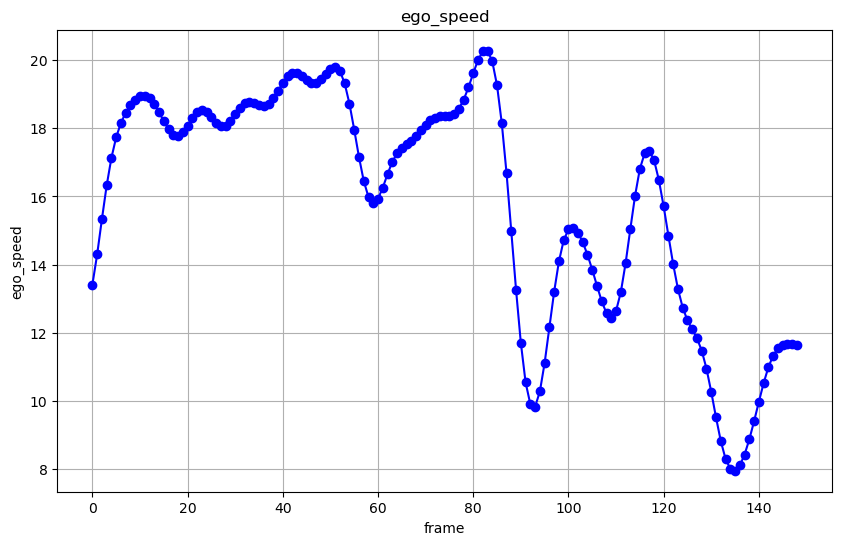

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))  # 그래프 크기 설정
plt.plot(ego_speed, marker='o', linestyle='-', color='b')  # 선과 마커 스타일 설정
plt.title("ego_speed")  # 그래프 제목 설정
plt.xlabel("frame")  # x축 라벨
plt.ylabel("ego_speed")  # y축 라벨
plt.grid(True)  # 그리드 표시
plt.show()  # 그래프 출력

vehicle1 [[916, 460, 33.542566233196446], [916, 460, 33.230502457422034], [916, 461, 32.339194205598744], [917, 461, 30.949632212223037], [917, 461, 30.915249245238684], [917, 462, 32.055513189857216], [918, 462, 32.31190385510604], [918, 461, 32.56743641619664], [919, 461, 34.01350688776973], [918, 461, 34.06263134546585], [918, 461, 34.36139254418276], [918, 461, 32.76232984618543], [917, 461, 31.58797126101816], [918, 462, 30.837386863526167], [919, 462, 30.219350187864197], [919, 461, 31.222562715969516], [919, 460, 31.21452933638524], [919, 460, 32.38792996782656], [918, 460, 35.207435758856136], [918, 459, 35.88321771530322], [917, 458, 37.0550885762349], [917, 458, 36.483435066599185], [917, 458, 33.79461384746731], [917, 459, 31.38532808344605], [917, 460, 31.09721081604812], [917, 459, 30.460467204096595], [918, 460, 30.45578258143128], [917, 460, 30.804736601378558], [917, 461, 31.238433596809113], [917, 463, 31.35108914682067], [917, 463, 31.53162641457237], [917, 463, 31.71

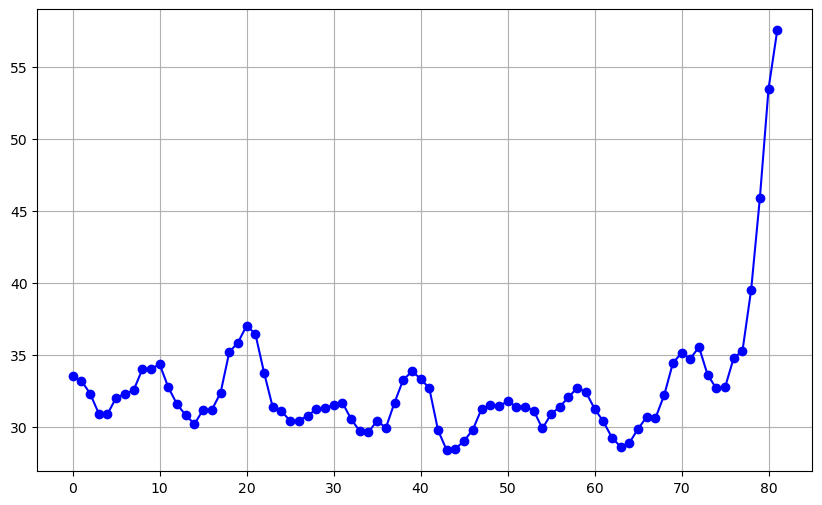

vehicle28 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

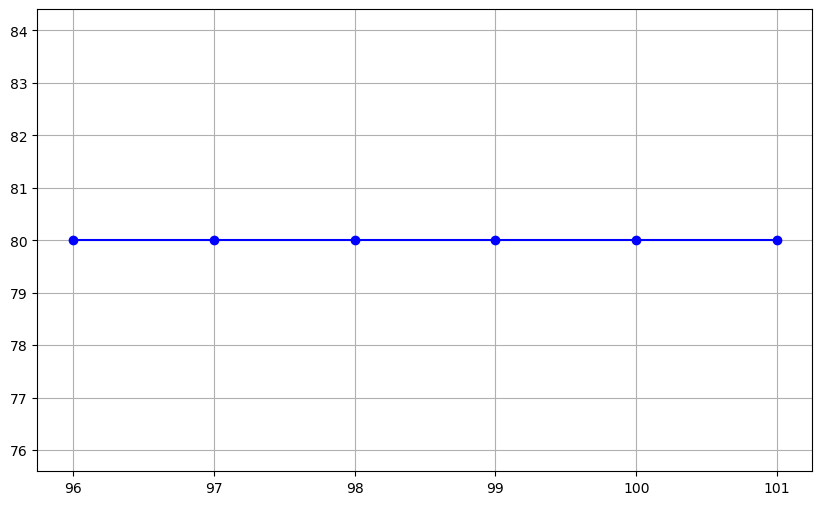

vehicle36 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

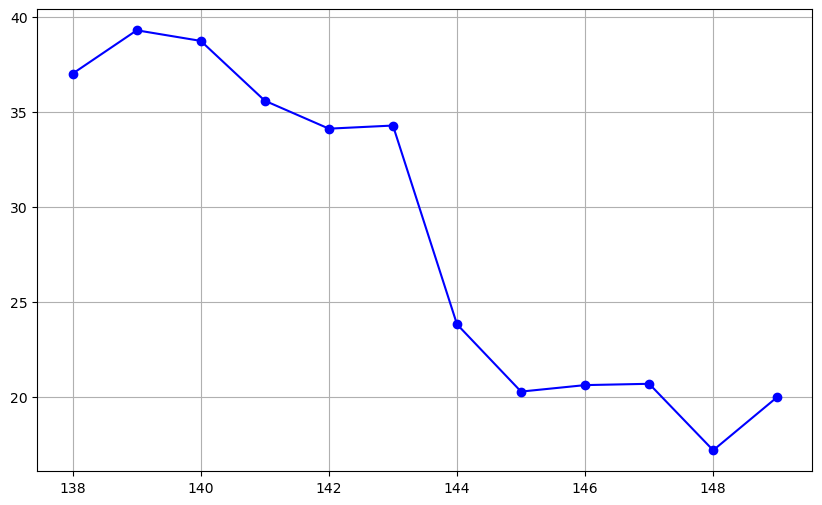

vehicle31 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

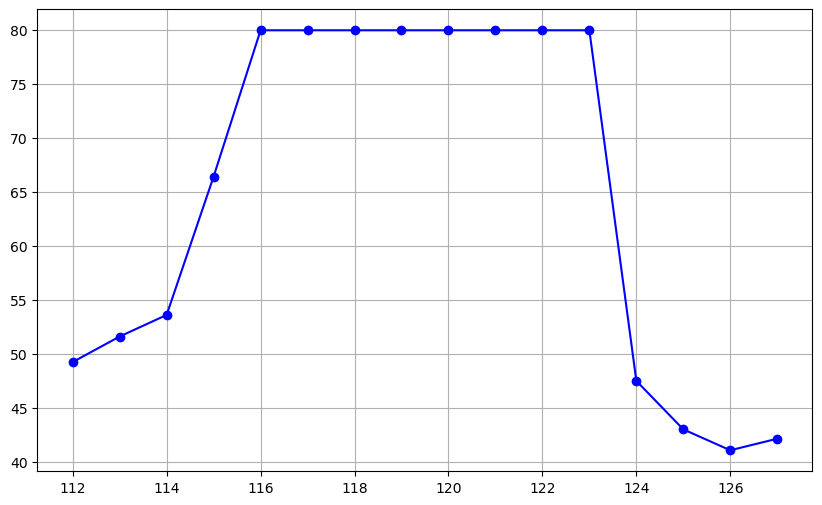

vehicle16 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [489, 371, 72.66399809993985], [450, 366, 63.63739463186876], [394, 354, 51.11702578564471], [320, 338, 51.865810746901175], [293, 336, 44.17088878183522], [258, 324, 43.44252123453984], [169, 311, 39.990550225597445], [30, 283, 33.19103011702536], 

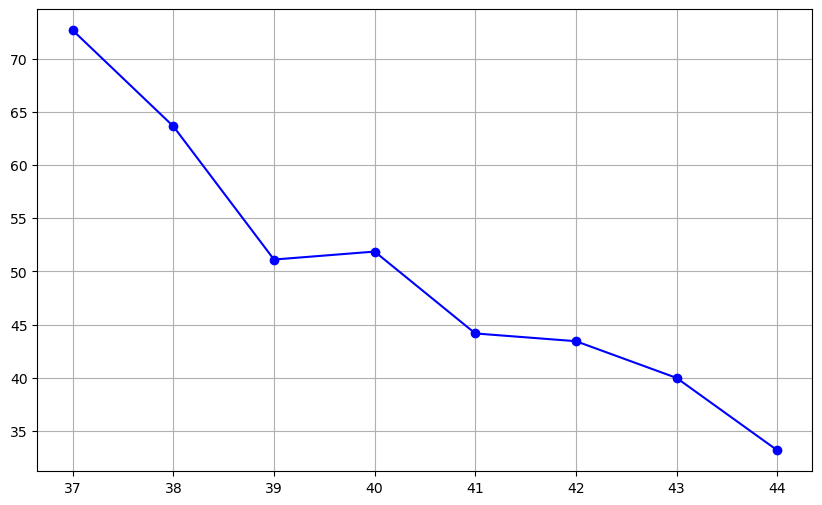

vehicle0 [[1028, 465, 68.53464657812617], [1028, 465, 71.71715247198635], [1029, 465, 73.94334163651044], [1030, 465, 74.11722701507614], [1030, 465, 76.63173522502316], [1032, 466, 73.16964967425126], [1034, 465, 74.4085725153471], [1035, 464, 79.06109467060479], [1036, 464, 80.0], [1037, 464, 80.0], [1038, 464, 80.0], [1039, 464, 80.0], [1040, 465, 79.36465472462245], [1043, 466, 80.0], [1044, 466, 80.0], [1046, 465, 80.0], [1048, 464, 77.03726944831112], [1050, 464, 77.82874531705355], [1053, 463, 77.95014277998666], [1054, 463, 71.59076118341017], [1055, 463, 70.30013173832417], [1058, 463, 68.95933915829643], [1061, 463, 67.67307220509039], [1064, 463, 64.00355942306427], [1066, 463, 57.21250251623709], [1070, 463, 57.60773525085682], [1072, 464, 55.058081577469935], [1075, 464, 57.74860613194282], [1077, 465, 55.35077047454056], [1080, 466, 57.3888949740178], [1084, 467, 52.55140280784265], [1086, 467, 55.965152514029], [1090, 467, 51.236578838218705], [1094, 467, 52.976636058246

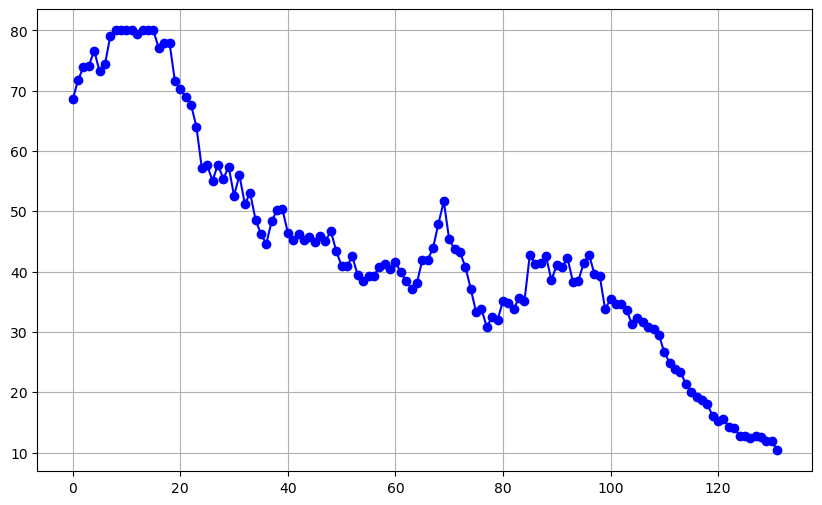

vehicle25 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

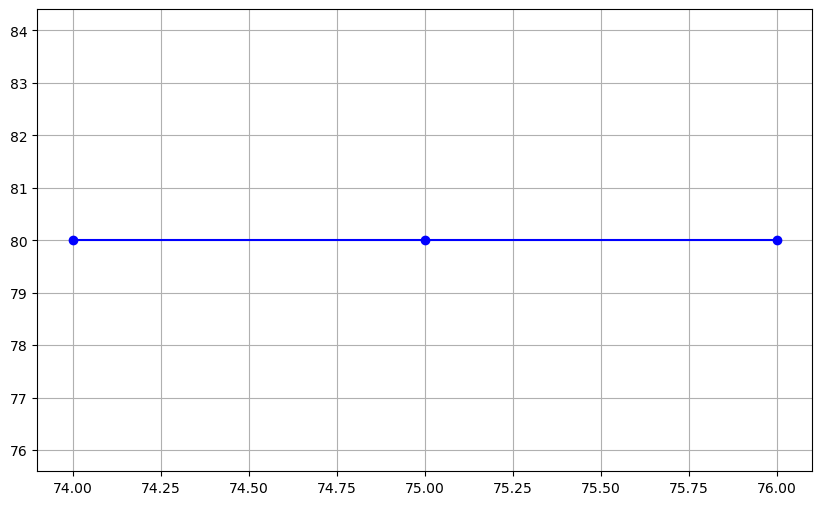

vehicle13 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [910, 446, 52.24292430749487], [910, 445, 56.090225178860024], [910, 444, 44.78961537849504], [910, 444, 38.05504126324078], [910, 444, 37.044331249441754], [911, 443, 38.060468293832294], [910, 442, 37.60774170583687], [909, 440, 47.59944427282994], [908, 440, 58.04261878291303], [907, 439, 56.076325630009315], [906, 440, 61.571514533666786], [905, 440, 71.62595309119321], [904, 441, 6

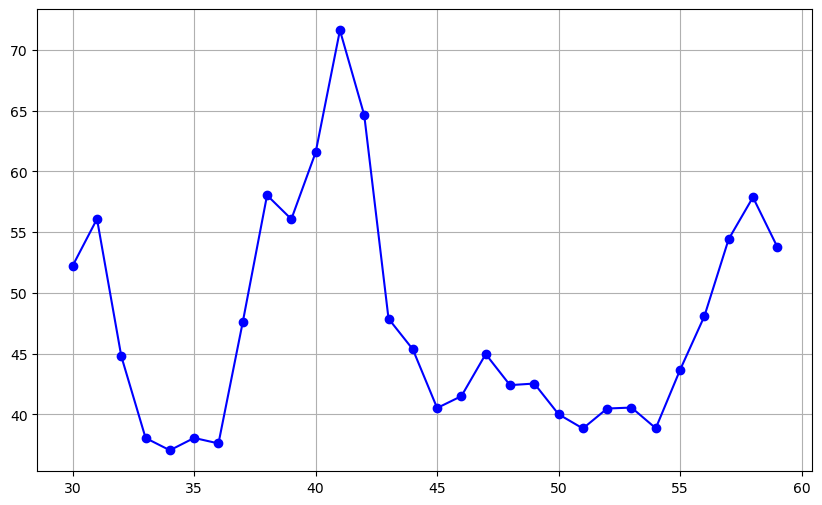

vehicle27 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

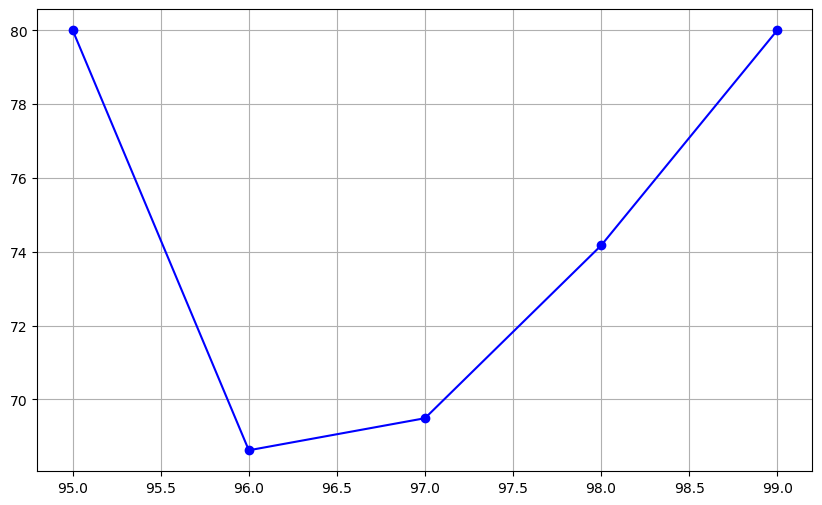

vehicle29 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

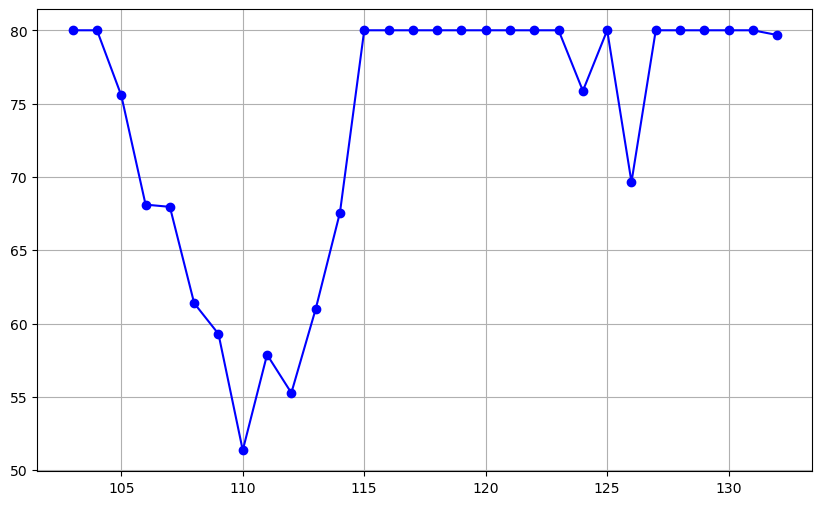

vehicle10 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [752, 424, 80.0], [746, 424, 80.0], [740, 424, 80.0], [730, 424, 80.0], [724, 423, 80.0], [715, 422, 80.0], [703, 420, 80.0], [690, 417, 80.0], [670, 414, 80.0], [661, 410, 80.0], [643, 408, 80.0], [623, 403, 72.19279916314954], [599, 397, 80.0], [577, 392, 80.0], [545, 386, 80.0], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None,

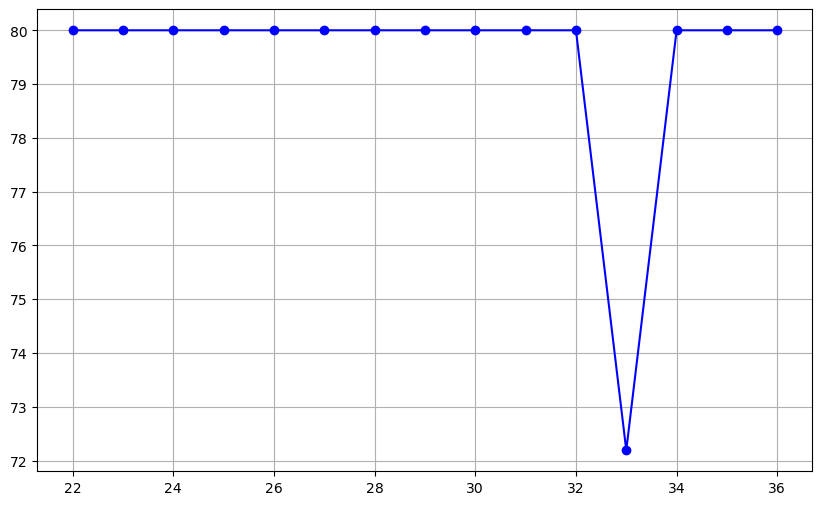

vehicle19 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [960, 449, 49.83791905147928], [960, 448, 57.63642788383267], [960, 449, 79.4651020280830

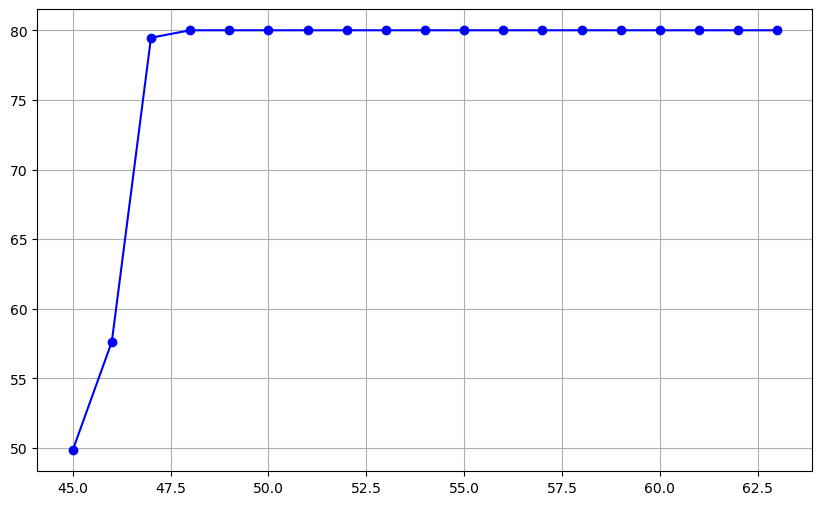

vehicle8 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [915, 449, 43.03464241307], [915, 448, 43.62207245277975], [915, 447, 44.18652694370554], [916, 446, 49.564864008850144], [917, 445, 55.461214159382656], [917, 444, 55.58670890701573], [916, 443, 63.866515437384166], [915, 442, 65.25602361335368], [914, 442, 64.93203480730331], [914, 441, 67.49153444774255], [914, 441, 64.54325699464837], [914, 441, 60.723893169594284], [912, 442, 52.97194947374056], [913, 443, 40.17778750769827], [912, 444, 38.084927663201896], [912, 444, 40.08862449777532], [911, 445, 40.05540244260344], [910, 446, 39.91443504509947], [910, 446, 39.56014504891125], [911, 447, 37.263857402256974], [911, 448, 33.628763538825304], [910, 448, 31.524336245341914], [911, 448, 30.558806312985045], [911, 447, 31.744098681729177],

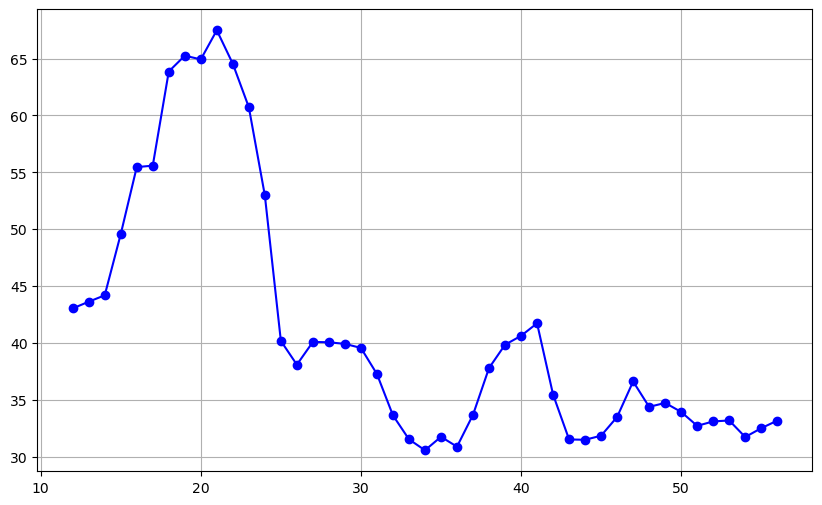

In [23]:
# drop 전 vehicle depth visualization
# None 값과 nan값 개수 확인
import matplotlib.pyplot as plt
for vehicle, coors in vehicle_coor.items():
    print(vehicle, coors)
    depths = [point[2] for point in coors]
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    print(f'None+nan 개수: {depths.count(None)+nan_cnt}')
    print(f'nan 개수: {nan_cnt}')
    
    plt.figure(figsize=(10, 6))  
    plt.plot(depths, marker='o', linestyle='-', color='b') 
    plt.grid(True)  
    plt.show()  

In [24]:
# None, nan 개수 합이 150개이면 drop
dropped = {}
for vehicle, coors in vehicle_coor.items():
    depths = [point[2] for point in coors]
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    if depths.count(None)+nan_cnt != len(depths):
        dropped[vehicle] = coors

print(f'{len(vehicle_coor)} {vehicle_coor.keys()}')
print(f'{len(dropped)} {dropped.keys()}')

13 dict_keys(['vehicle1', 'vehicle28', 'vehicle36', 'vehicle31', 'vehicle16', 'vehicle0', 'vehicle25', 'vehicle13', 'vehicle27', 'vehicle29', 'vehicle10', 'vehicle19', 'vehicle8'])
13 dict_keys(['vehicle1', 'vehicle28', 'vehicle36', 'vehicle31', 'vehicle16', 'vehicle0', 'vehicle25', 'vehicle13', 'vehicle27', 'vehicle29', 'vehicle10', 'vehicle19', 'vehicle8'])


vehicle1 [[916, 460, 33.542566233196446], [916, 460, 33.230502457422034], [916, 461, 32.339194205598744], [917, 461, 30.949632212223037], [917, 461, 30.915249245238684], [917, 462, 32.055513189857216], [918, 462, 32.31190385510604], [918, 461, 32.56743641619664], [919, 461, 34.01350688776973], [918, 461, 34.06263134546585], [918, 461, 34.36139254418276], [918, 461, 32.76232984618543], [917, 461, 31.58797126101816], [918, 462, 30.837386863526167], [919, 462, 30.219350187864197], [919, 461, 31.222562715969516], [919, 460, 31.21452933638524], [919, 460, 32.38792996782656], [918, 460, 35.207435758856136], [918, 459, 35.88321771530322], [917, 458, 37.0550885762349], [917, 458, 36.483435066599185], [917, 458, 33.79461384746731], [917, 459, 31.38532808344605], [917, 460, 31.09721081604812], [917, 459, 30.460467204096595], [918, 460, 30.45578258143128], [917, 460, 30.804736601378558], [917, 461, 31.238433596809113], [917, 463, 31.35108914682067], [917, 463, 31.53162641457237], [917, 463, 31.71

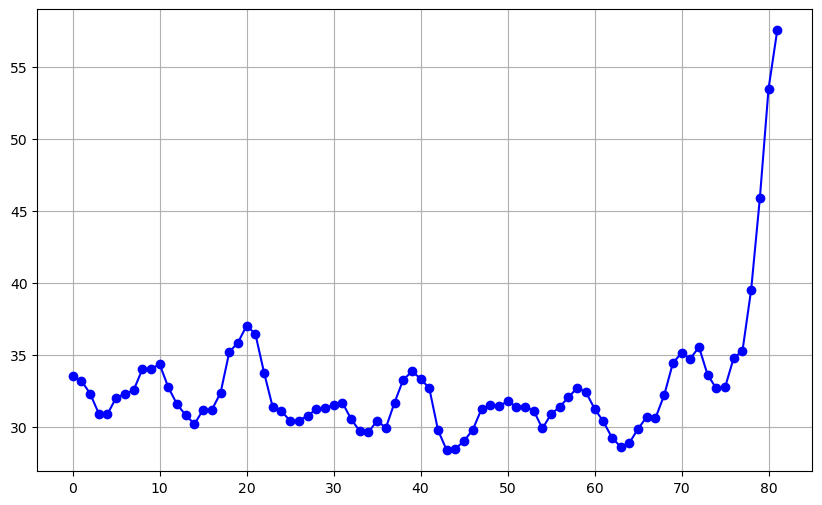

vehicle28 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

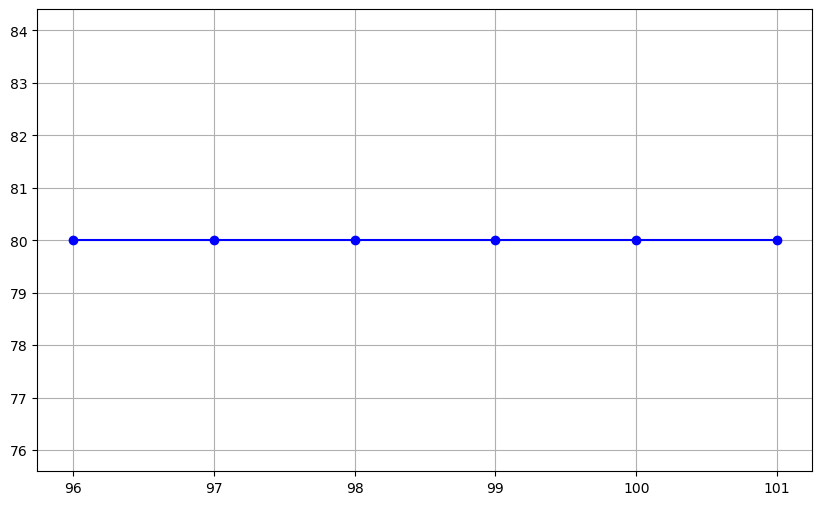

vehicle36 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

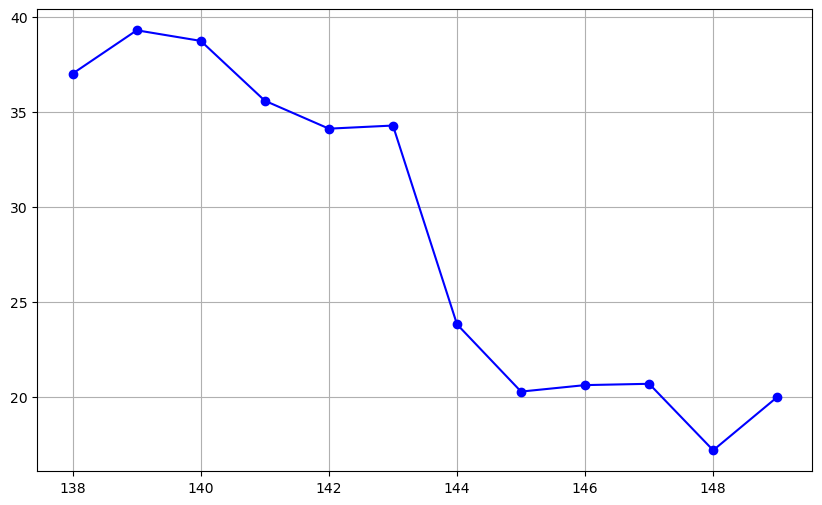

vehicle31 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

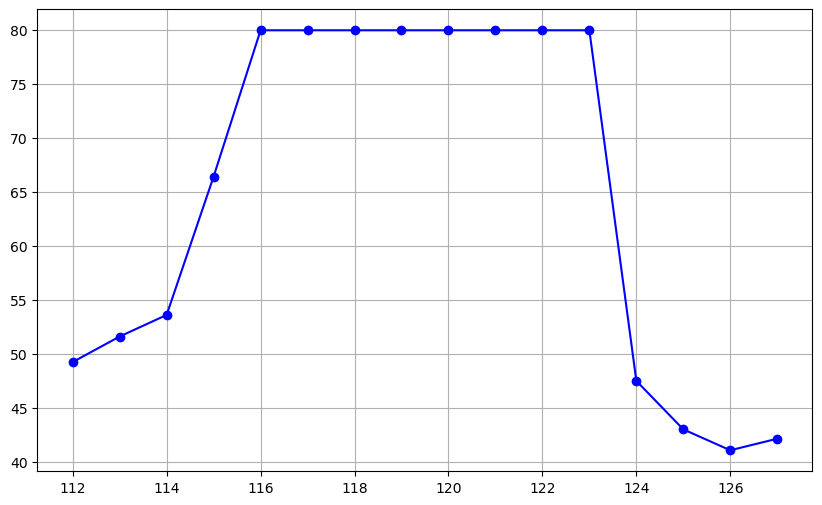

vehicle16 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [489, 371, 72.66399809993985], [450, 366, 63.63739463186876], [394, 354, 51.11702578564471], [320, 338, 51.865810746901175], [293, 336, 44.17088878183522], [258, 324, 43.44252123453984], [169, 311, 39.990550225597445], [30, 283, 33.19103011702536], 

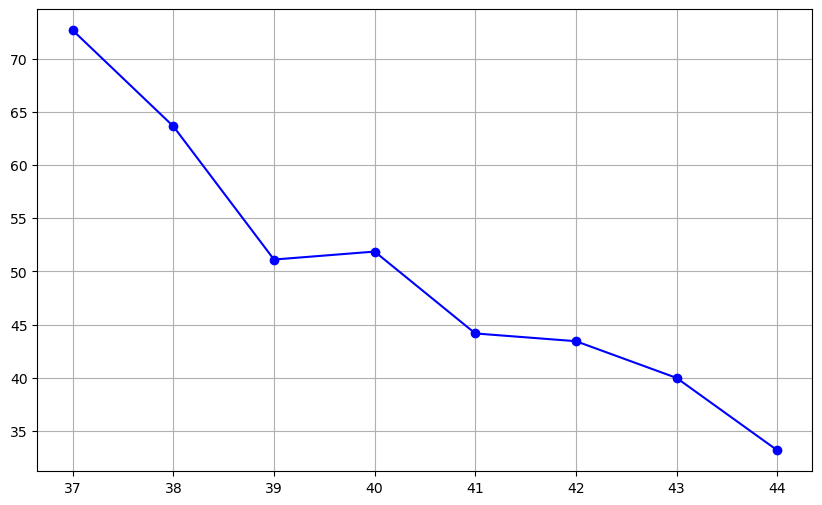

vehicle0 [[1028, 465, 68.53464657812617], [1028, 465, 71.71715247198635], [1029, 465, 73.94334163651044], [1030, 465, 74.11722701507614], [1030, 465, 76.63173522502316], [1032, 466, 73.16964967425126], [1034, 465, 74.4085725153471], [1035, 464, 79.06109467060479], [1036, 464, 80.0], [1037, 464, 80.0], [1038, 464, 80.0], [1039, 464, 80.0], [1040, 465, 79.36465472462245], [1043, 466, 80.0], [1044, 466, 80.0], [1046, 465, 80.0], [1048, 464, 77.03726944831112], [1050, 464, 77.82874531705355], [1053, 463, 77.95014277998666], [1054, 463, 71.59076118341017], [1055, 463, 70.30013173832417], [1058, 463, 68.95933915829643], [1061, 463, 67.67307220509039], [1064, 463, 64.00355942306427], [1066, 463, 57.21250251623709], [1070, 463, 57.60773525085682], [1072, 464, 55.058081577469935], [1075, 464, 57.74860613194282], [1077, 465, 55.35077047454056], [1080, 466, 57.3888949740178], [1084, 467, 52.55140280784265], [1086, 467, 55.965152514029], [1090, 467, 51.236578838218705], [1094, 467, 52.976636058246

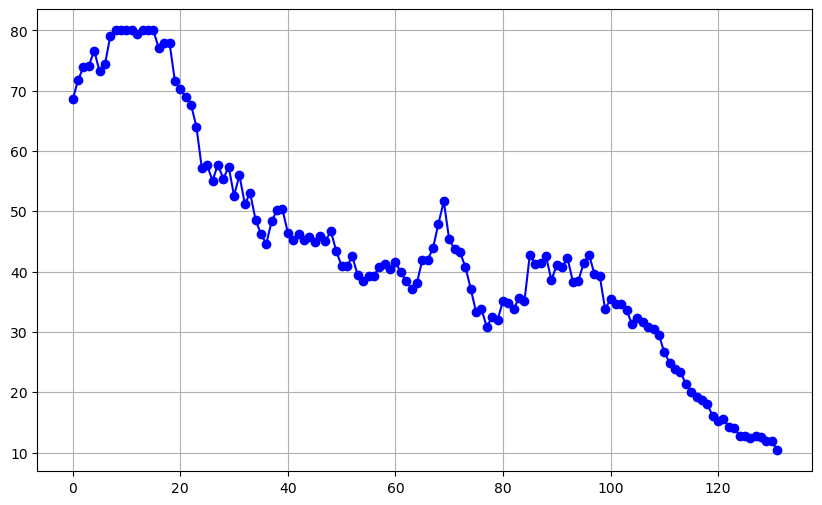

vehicle25 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

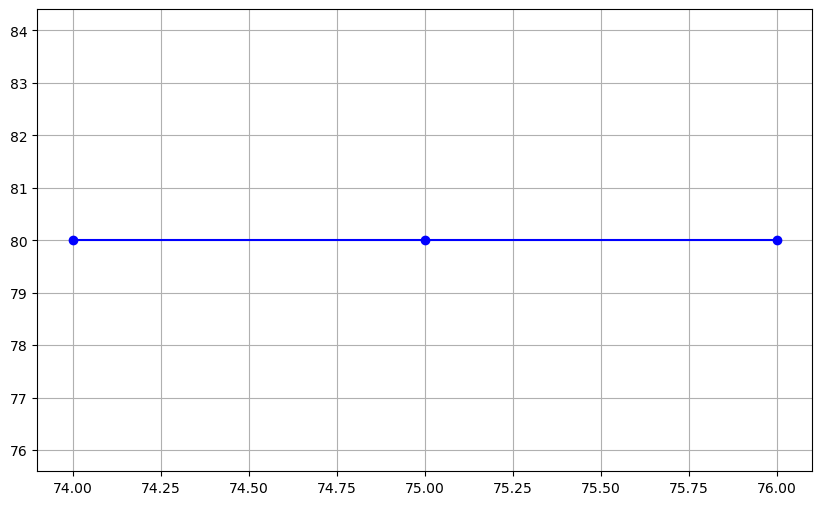

vehicle13 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [910, 446, 52.24292430749487], [910, 445, 56.090225178860024], [910, 444, 44.78961537849504], [910, 444, 38.05504126324078], [910, 444, 37.044331249441754], [911, 443, 38.060468293832294], [910, 442, 37.60774170583687], [909, 440, 47.59944427282994], [908, 440, 58.04261878291303], [907, 439, 56.076325630009315], [906, 440, 61.571514533666786], [905, 440, 71.62595309119321], [904, 441, 6

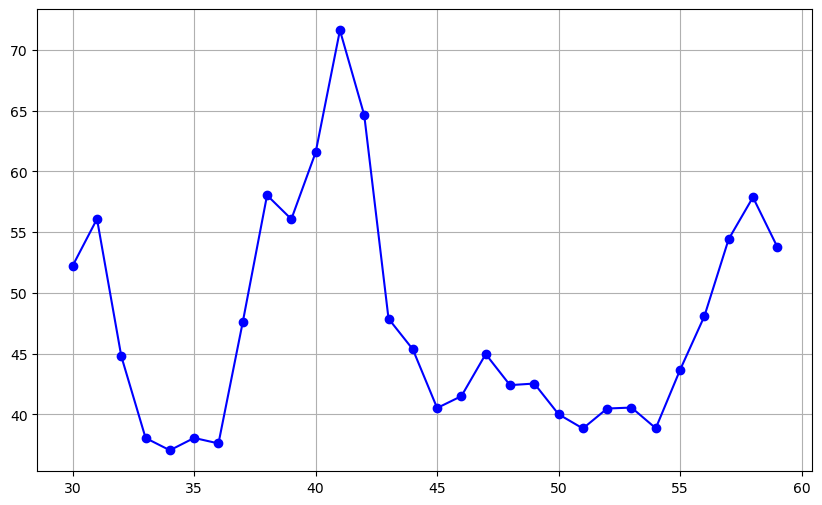

vehicle27 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

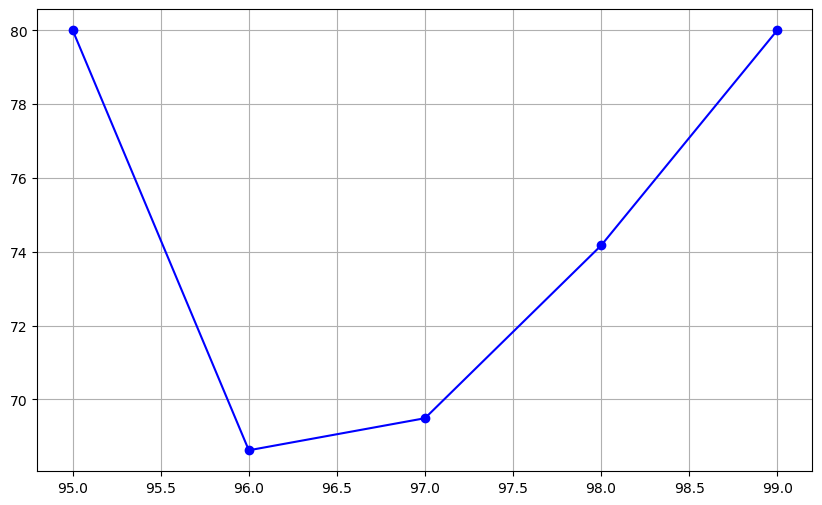

vehicle29 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, No

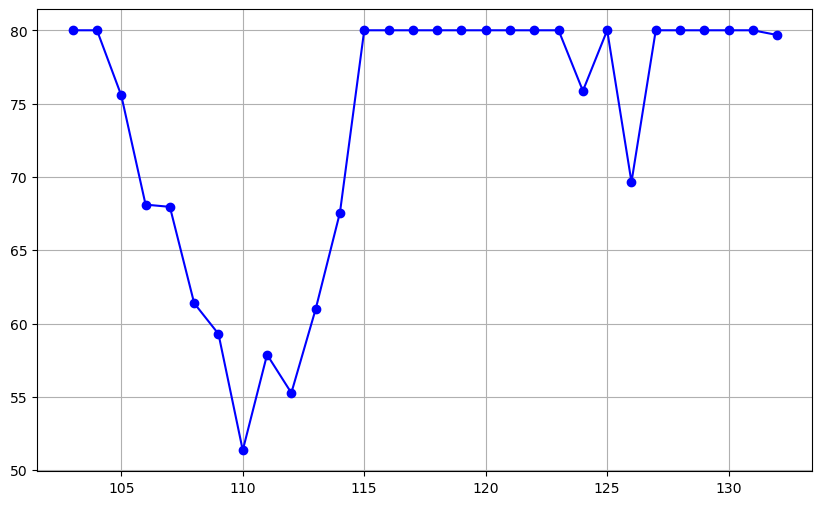

vehicle10 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [752, 424, 80.0], [746, 424, 80.0], [740, 424, 80.0], [730, 424, 80.0], [724, 423, 80.0], [715, 422, 80.0], [703, 420, 80.0], [690, 417, 80.0], [670, 414, 80.0], [661, 410, 80.0], [643, 408, 80.0], [623, 403, 72.19279916314954], [599, 397, 80.0], [577, 392, 80.0], [545, 386, 80.0], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None,

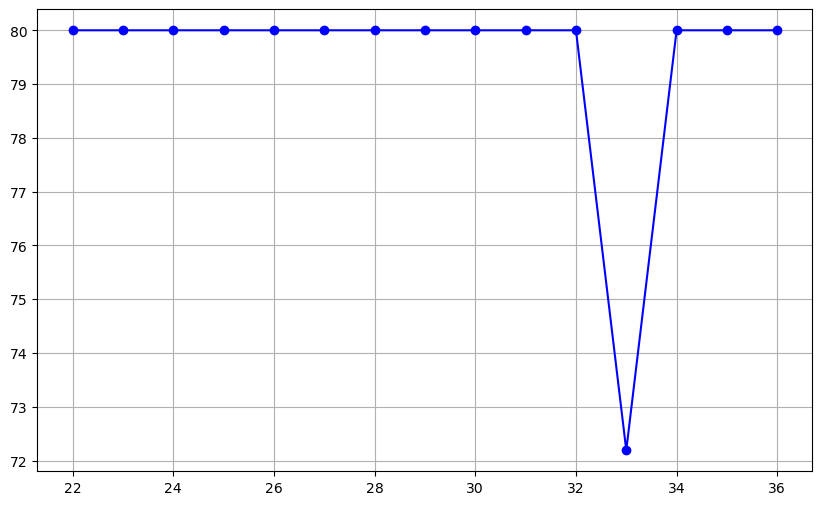

vehicle19 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [960, 449, 49.83791905147928], [960, 448, 57.63642788383267], [960, 449, 79.4651020280830

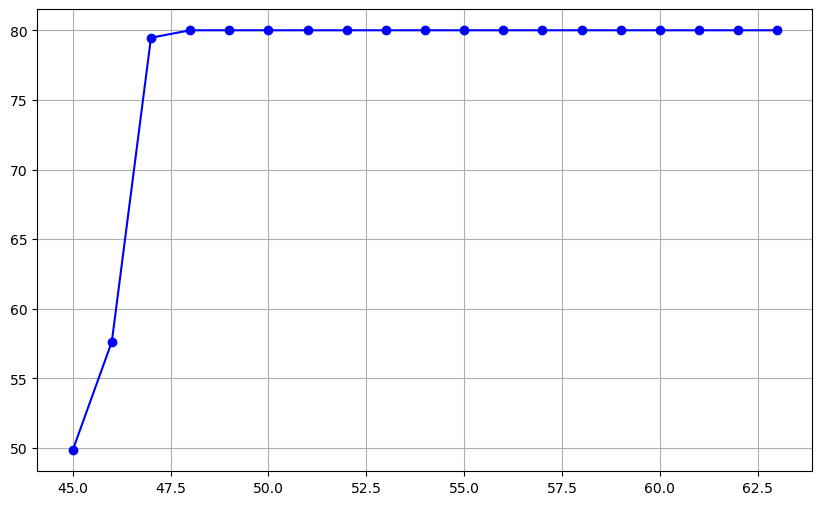

vehicle8 [[None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [None, None, None], [915, 449, 43.03464241307], [915, 448, 43.62207245277975], [915, 447, 44.18652694370554], [916, 446, 49.564864008850144], [917, 445, 55.461214159382656], [917, 444, 55.58670890701573], [916, 443, 63.866515437384166], [915, 442, 65.25602361335368], [914, 442, 64.93203480730331], [914, 441, 67.49153444774255], [914, 441, 64.54325699464837], [914, 441, 60.723893169594284], [912, 442, 52.97194947374056], [913, 443, 40.17778750769827], [912, 444, 38.084927663201896], [912, 444, 40.08862449777532], [911, 445, 40.05540244260344], [910, 446, 39.91443504509947], [910, 446, 39.56014504891125], [911, 447, 37.263857402256974], [911, 448, 33.628763538825304], [910, 448, 31.524336245341914], [911, 448, 30.558806312985045], [911, 447, 31.744098681729177],

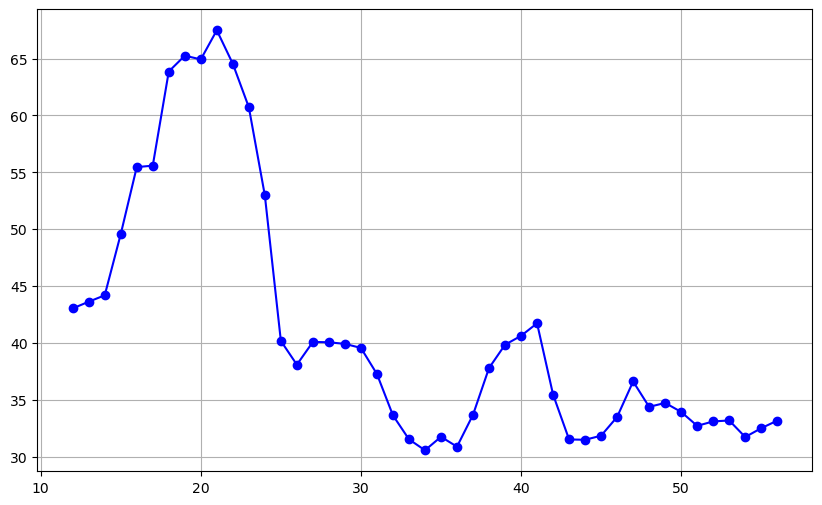

In [25]:
# dropped re visualization
import matplotlib.pyplot as plt
for vehicle, coors in dropped.items():
    print(vehicle, coors)
    depths = [point[2] for point in coors]
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    print(f'None+nan 개수: {depths.count(None)+nan_cnt}')
    print(f'nan 개수: {nan_cnt}')
    
    plt.figure(figsize=(10, 6))  
    plt.plot(depths, marker='o', linestyle='-', color='b') 
    plt.grid(True)
    plt.show()

In [26]:
# velocity dic에서 None값 평균값으로 치환
vel_without_None = {}
for vehicle in dropped.keys():
    cleaned_data = [x for x in velocity_dic[vehicle] if x is not None and not (isinstance(x, float) and np.isnan(x))]
    # print(cleaned_data)
    mean = np.mean(cleaned_data)
    print(vehicle, mean)
    filled_velocity = [mean if x is None or np.isnan(x) else x for x in velocity_dic[vehicle]]
    # print(filled_velocity)
    vel_without_None[vehicle] = filled_velocity

vehicle1 16.23424356693298
vehicle28 6.197916996682665
vehicle36 48.68375827374318
vehicle31 73.63391588601006
vehicle16 98.33474578676113
vehicle0 27.105703072706447
vehicle25 4.263588975795681
vehicle13 68.30383462003034
vehicle27 89.2311459996082
vehicle29 49.8709615782837
vehicle10 29.079834192116078
vehicle19 27.376893006886483
vehicle8 35.26939680392581


vehicle1 [4.71092276181802, 13.54161933284542, 20.98851095103104, 0.5189586309187436, 17.15358819978617, 3.8748337140029467, 3.9803427755649174, 21.81686323635536, 0.8473885557074948, 4.509237072778659, 24.134836888036997, 17.716973717292255, 11.429185721328544, 9.344022856935847, 15.218697398847693, 0.6325321520404468, 17.712400008852764, 42.57453744852978, 10.305022716388738, 17.808302453385462, 8.63201133072147, 40.60140423981843, 36.45617292481643, 4.463098213044194, 9.565288276786355, 0.7203621888001439, 5.2903209336292285, 6.509301055466663, 2.012980628002564, 2.7241662133987794, 2.794898553441871, 17.2799782224064, 12.630304917484505, 1.1839716693999043, 12.277291787904714, 7.755139694178643, 26.83486716654019, 23.9675539469116, 8.853142279144041, 7.5128094472798574, 10.382796108641566, 43.71332612039883, 21.031659482116222, 1.5556218836624263, 8.304868604383062, 11.697865765031228, 21.461253386171382, 4.103191624685453, 1.2447026956836018, 5.481874987536846, 5.833485069697564, 

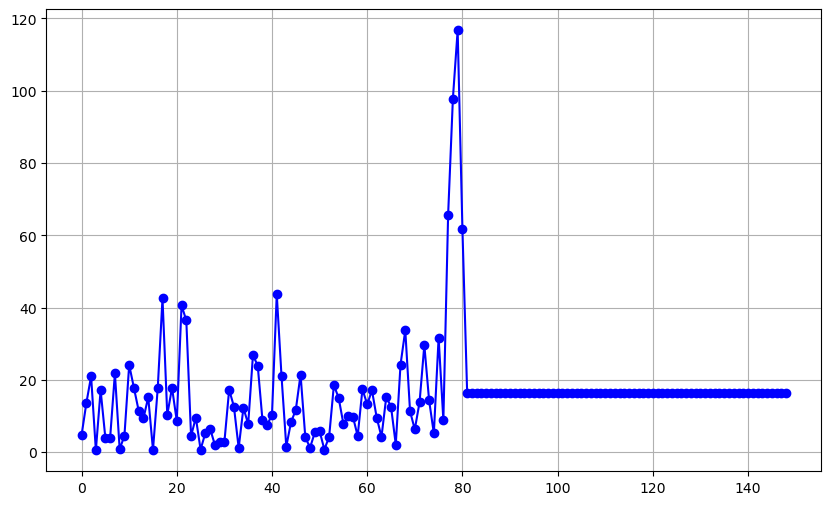

vehicle28 [6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6.197916996682665, 6

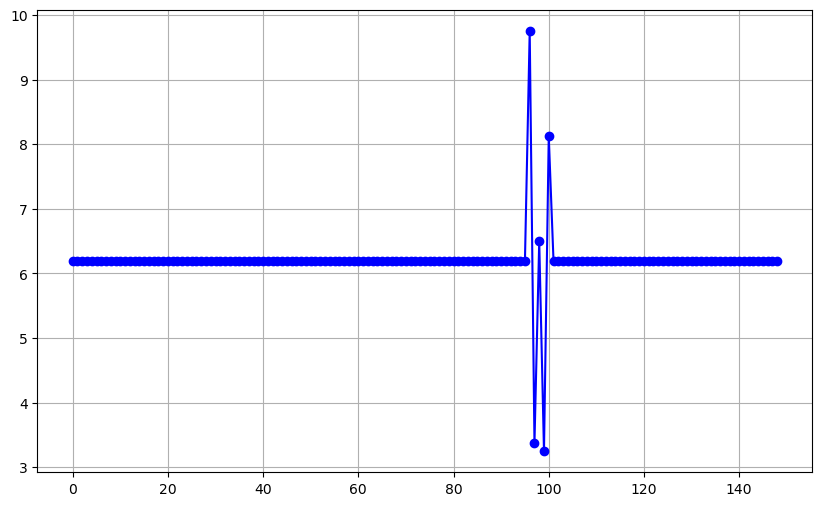

vehicle36 [48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 48.68375827374318, 4

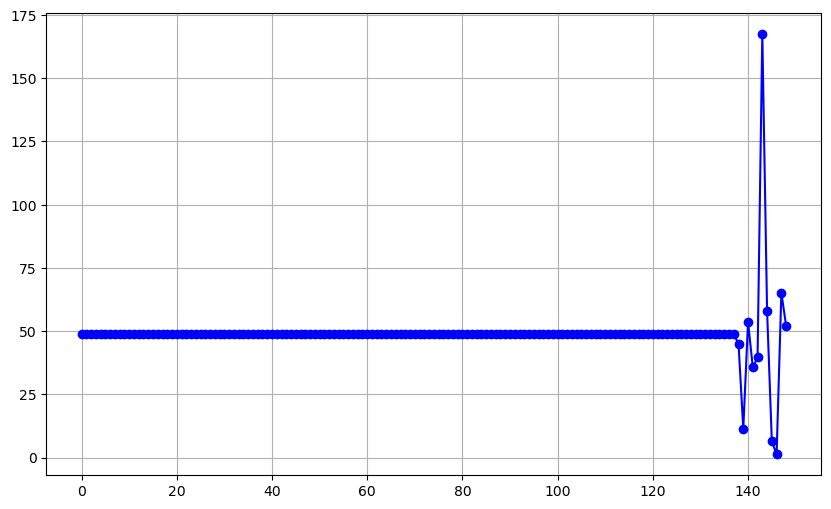

vehicle31 [73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 73.63391588601006, 7

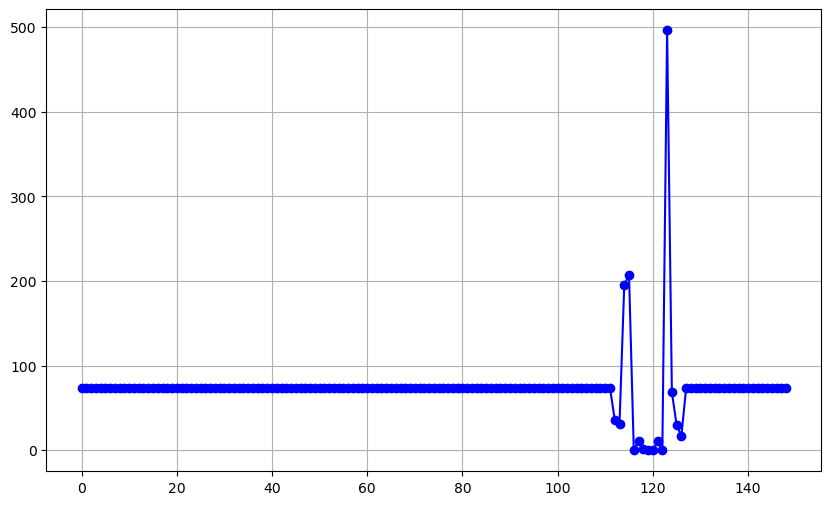

vehicle16 [98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 139.06923797938208, 194.65684698947663, 53.575046351529316, 126.5551392649242, 17.763929352430843, 53.56819842616207, 103.15482214342289, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.33474578676113, 98.334745786761

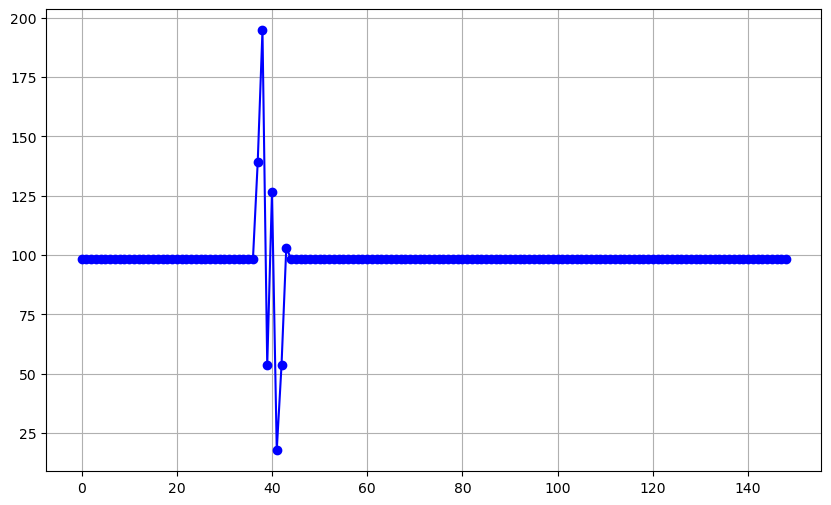

vehicle0 [48.04627387944054, 33.662494320262624, 2.799200461789274, 37.9644989051794, 52.38059741536327, 19.080991030532942, 70.49202659730184, 14.261222813431885, 0.9112932009933106, 0.9112932009932972, 0.9112932009933106, 9.88196411833615, 10.110927671571355, 0.9112932009933106, 2.4414337437627696, 44.553383232834655, 12.207641176178534, 3.7714550131743687, 96.09015195111682, 19.473000095072532, 20.24111934308643, 19.418335612266834, 55.378285269996205, 102.63938955761101, 6.719518763012478, 38.63269721669924, 40.92948338431993, 36.338300320650546, 30.98832578636268, 73.16131854900384, 51.81561391271866, 71.41300872341003, 26.698573791094645, 66.01966272957978, 36.324864074435496, 23.753285999835413, 57.77555126320652, 27.209290784272966, 3.24665253802205, 57.94186291292289, 19.733423882806814, 16.114389835790657, 15.021087125916962, 7.876688513103154, 11.208154863407984, 13.837018264835, 11.04416180135599, 23.629540982196183, 48.9708411573127, 38.872170857675, 0.9902950930664719, 24

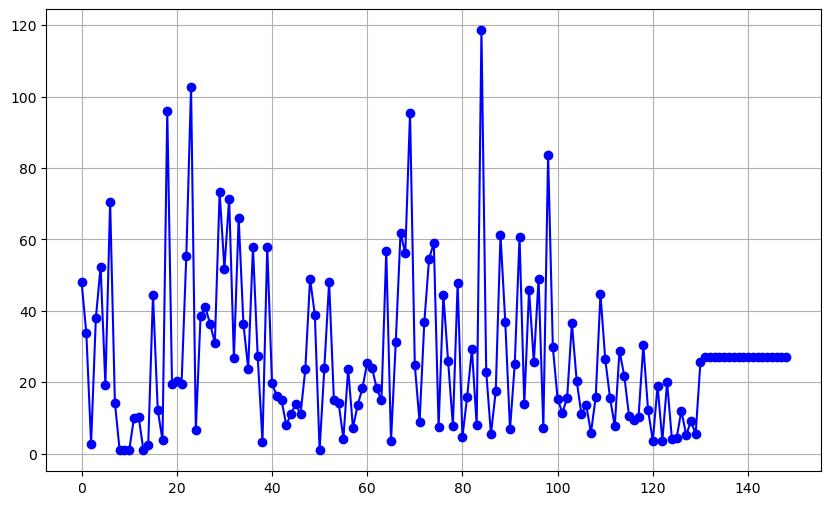

vehicle25 [4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4.263588975795681, 4

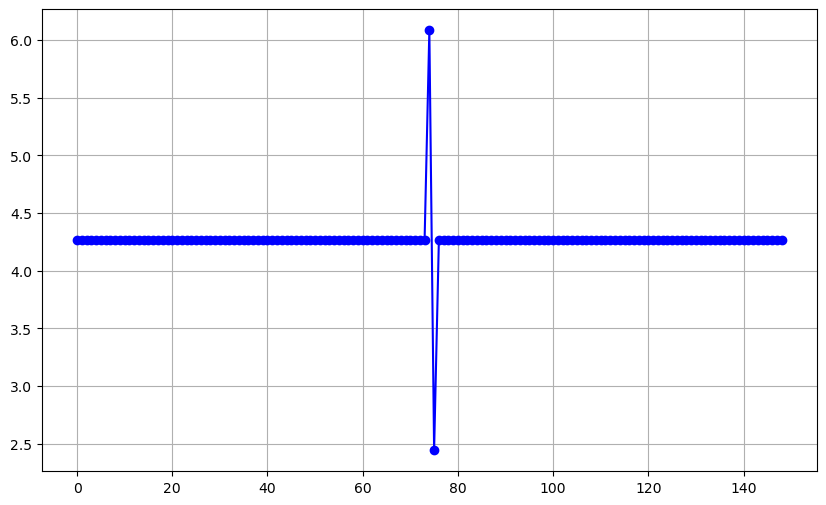

vehicle13 [68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 68.30383462003034, 58.37070334359224, 170.9126990148706, 101.94024004846088, 15.298966150314037, 15.489470388157997, 6.794378297794829, 151.58317325078264, 158.21949179622936, 29.636823517005435, 83.13177083710958, 152.35307439997058, 106.01581569094233, 253.86381806077563, 38.3387505180505, 73.13828283530843, 14.749507249623296, 52.30077327495113, 38.71293316526227, 2.0050395009415576, 38.44114827154037, 17.64670353668163, 24.8801164

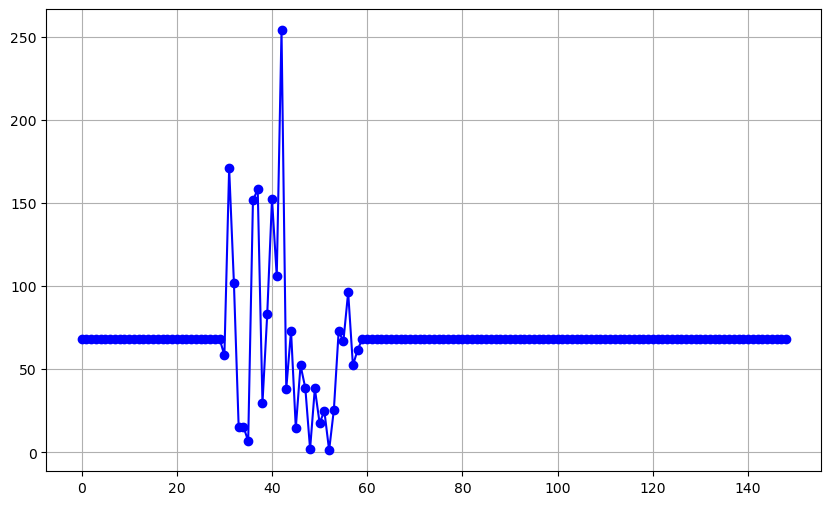

vehicle27 [89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082, 89.2311459996082,

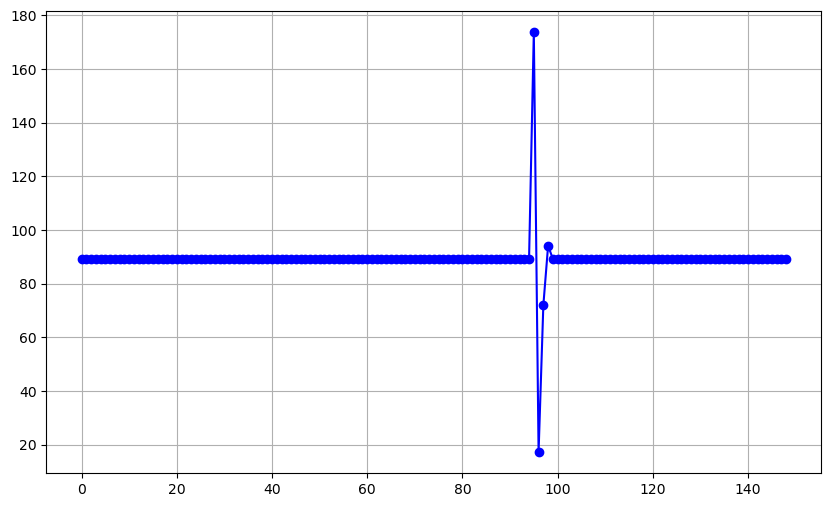

vehicle29 [49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837, 49.8709615782837,

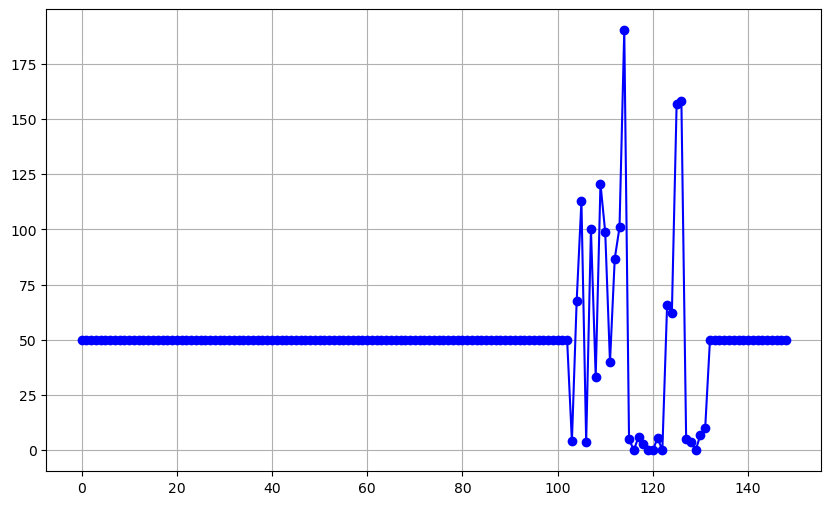

vehicle10 [29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 5.467759205959837, 5.467759205959863, 9.112932009933106, 5.70396075256798, 8.360960272886377, 11.407921505135928, 12.809993879161093, 18.866136781623972, 10.463618861175132, 16.721920545772754, 118.47818045955954, 131.87824392375896, 21.63122286486402, 30.747068421266537, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.079834192116078, 29.0798341921160

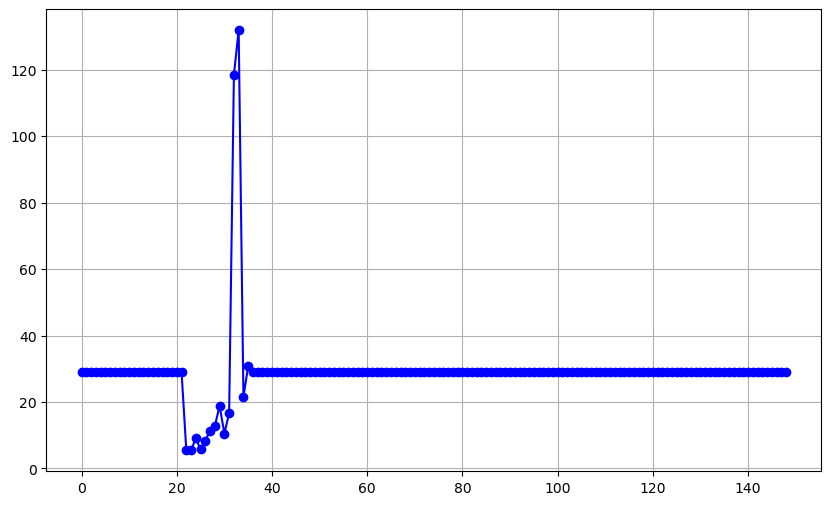

vehicle19 [27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 27.376893006886483, 118.01065032270547, 329.7640608262016, 8.63276702587886, 1.8225864019866194, 3.1800747186

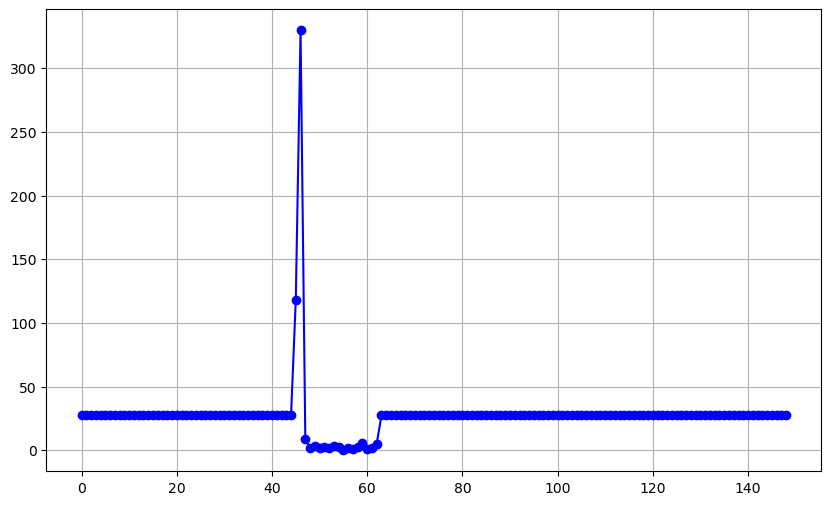

vehicle8 [35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 35.26939680392581, 9.03426848358199, 8.693662601875872, 81.47319343458688, 89.33778567651461, 2.3294539800911336, 125.50633353950928, 21.283480973997474, 4.935849677914004, 38.95588917810911, 44.64626785139367, 57.83727721294667, 117.50110922526335, 193.84612972504402, 31.779729207890895, 30.327975645033554, 1.10060790464901, 2.4050212193960365, 5.361000733022145, 34.86871531910404, 55.08365128986448, 31.820719420949807, 14.62243500837771, 18.019908011212483, 13.068684465088594, 42.64967840410454, 62.21170885130062, 31.153239020358505, 11.786642026068282, 16.72316009007251, 94.88796186138485, 59.7196293569733, 0.9031505981461648, 5.436409778133716, 24.951642139825204, 47.02960045848892, 33.83323560667411, 5.240127512825072, 12.076810198406793, 18.399053428802123, 5.96268

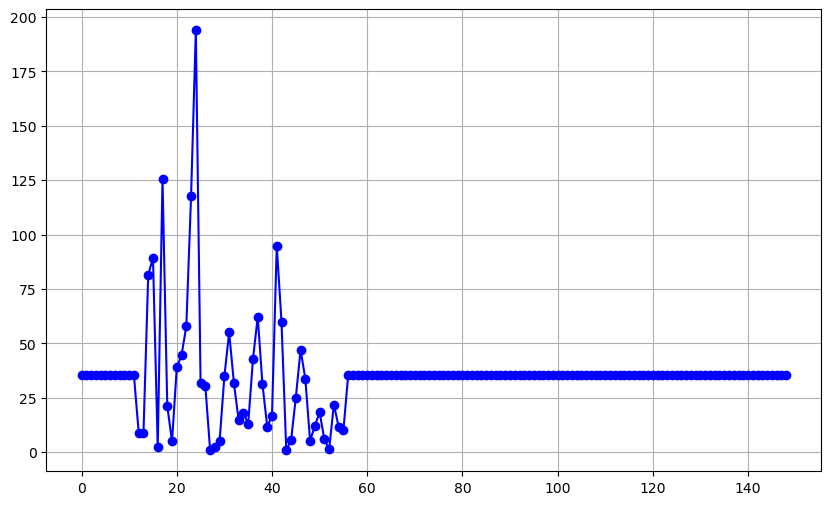

In [27]:
# filled re visualization
import matplotlib.pyplot as plt
for vehicle, coors in vel_without_None.items():
    print(vehicle, coors)
    # depths = [point[2] for point in coors]
    depths = coors
    nan_cnt = sum(1 for d in depths if isinstance(d, float) and np.isnan(d))
    print(f'None+nan 개수: {depths.count(None)+nan_cnt}')
    print(f'nan 개수: {nan_cnt}')
    
    plt.figure(figsize=(10, 6))  
    plt.plot(depths, marker='o', linestyle='-', color='b') 
    plt.grid(True)  
    plt.show() 

In [28]:
idx=0
print(depth_dic.keys())
vehicle = 'vehicle0'

dict_keys(['vehicle1', 'vehicle28', 'vehicle36', 'vehicle31', 'vehicle16', 'vehicle0', 'vehicle25', 'vehicle13', 'vehicle27', 'vehicle29', 'vehicle10', 'vehicle19', 'vehicle8'])


[1028, 1028, 1029, 1030, 1030, 1032, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1043, 1044, 1046, 1048, 1050, 1053, 1054, 1055, 1058, 1061, 1064, 1066, 1070, 1072, 1075, 1077, 1080, 1084, 1086, 1090, 1094, 1098, 1104, 1106, 1109, 1113, 1117, 1122, 1124, 1129, 1134, 1140, 1147, 1150, 1153, 1156, 1156, 1155, 1154, 1152, 1150, 1145, 1130, 1121, 1111, 1102, 1094, 1084, 1080, 1073, 1065, 1056, 1041, 1035, 1023, 1010, 994, 977, 972, 962, 952, 948, 937, 932, 923, 913, 906, 898, 898, 893, 891, 892, 902, 905, 915, 920, 934, 949, 958, 977, 986, 1014, 1035, 1056, 1078, 1089, 1123, 1150, 1174, 1200, 1213, 1252, 1273, 1289, 1301, 1309, 1329, 1338, 1351, 1369, 1378, 1410, 1437, 1460, 1460, 1491, 1521, 1521, 1521, 1594, 1594, 1648, 1675, 1703, 1751, 1785, 1809, 1828, 1865, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
[465, 465, 465, 465, 465, 466, 465, 464, 464, 464, 464, 464, 465, 466, 466, 465, 464, 464, 463, 463, 463, 463, 463, 463, 463

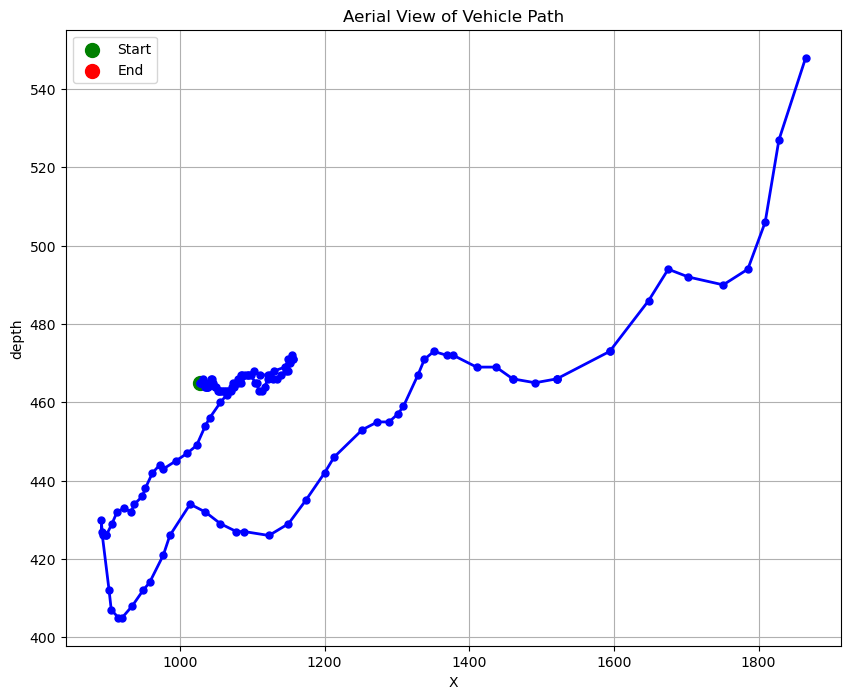

In [29]:
import matplotlib.pyplot as plt

vehicle = 'vehicle0'
points = depth_dic[vehicle]

x = [point[0] for point in points]
y = [point[1] for point in points]
z = [point[2] for point in points]
print(x)
print(y)
print(z)

plt.figure(figsize=(10, 8))
# plt.plot(x, z, marker='o', color='b', linestyle='-', linewidth=2, markersize=5)
plt.plot(x, y, marker='o', color='b', linestyle='-', linewidth=2, markersize=5)

# plt.scatter(x[0], z[0], color='g', s=100, label='Start')
# plt.scatter(x[-1], z[-1], color='r', s=100, label='End')
plt.scatter(x[0], y[0], color='g', s=100, label='Start')
plt.scatter(x[-1], y[-1], color='r', s=100, label='End')

plt.xlabel('X')
plt.ylabel('depth')

plt.title('Aerial View of Vehicle Path')

plt.legend()

plt.grid(True)
plt.show()


149
149


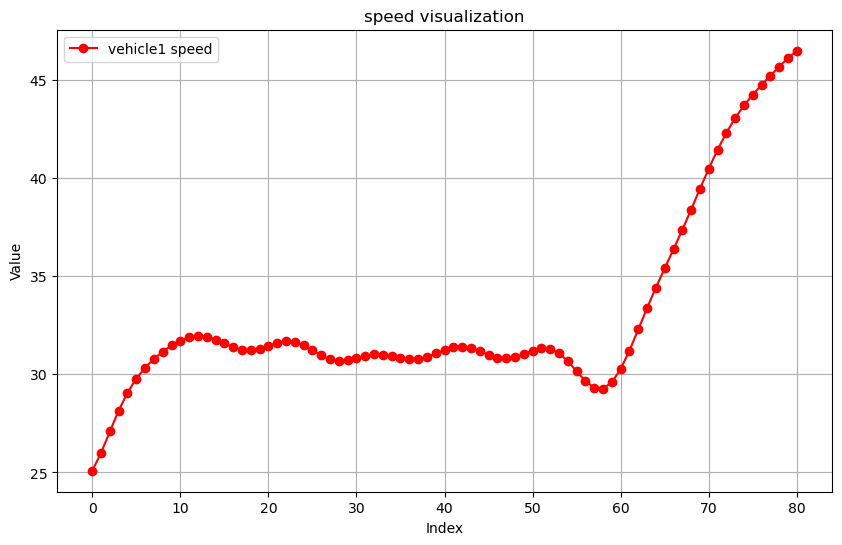

In [95]:
import matplotlib.pyplot as plt
import math

x = np.arange(0, len(velocity_dic['vehicle1'])) #흰색
data = np.array(velocity_dic['vehicle1'], dtype=np.float64)
data = np.where(data == None, np.nan, data)
data_filled = np.where(np.isnan(data), np.nanmean(data), data)
smoothed = gaussian_filter1d(data_filled, sigma=10)
smoothed = np.where(np.isnan(data), np.nan, smoothed)
y = list(smoothed)
print(len(y))
print(len(ego_speed))

result = []
for i, j in zip(y, ego_speed):
    if math.isnan(i) or math.isnan(j):
        result.append(float('nan'))
    else:
        result.append(i + j)
        
plt.figure(figsize=(10, 6))
plt.plot(x, result, color='red', marker='o', label='vehicle1 speed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('speed visualization')
plt.legend()
plt.grid(True)
plt.show()

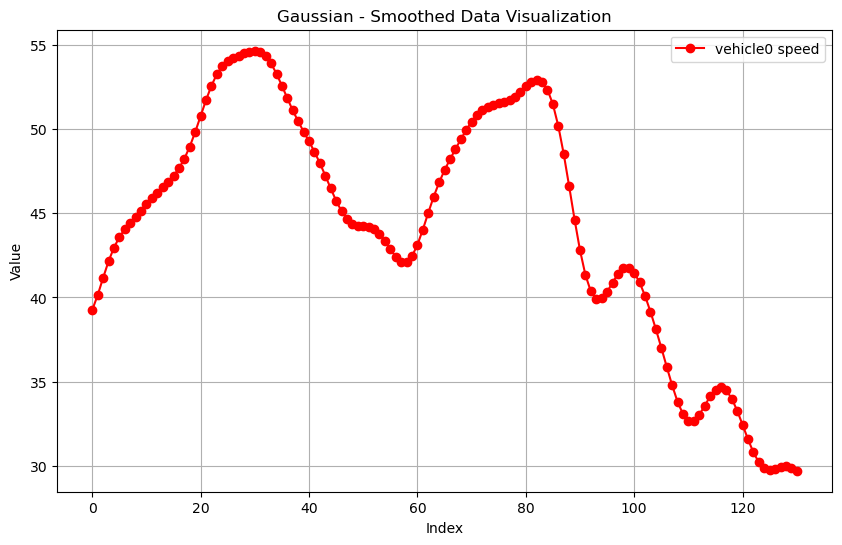

In [105]:
import matplotlib.pyplot as plt

x = np.arange(0, len(velocity_dic['vehicle0']))
data = np.array(velocity_dic['vehicle0'], dtype=np.float64)
data = np.where(data == None, np.nan, data)
data_filled = np.where(np.isnan(data), np.nanmean(data), data)
smoothed = gaussian_filter1d(data_filled, sigma=10)
smoothed = np.where(np.isnan(data), np.nan, smoothed)
y = list(smoothed)

result = []
for i, j in zip(y, ego_speed):
    if math.isnan(i) or math.isnan(j):
        result.append(float('nan'))
    else:
        result.append(i + j)
        
plt.figure(figsize=(10, 6))
plt.plot(x, result, color='red', marker='o', label='vehicle0 speed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Gaussian - Smoothed Data Visualization')
plt.legend()
plt.grid(True)
plt.show()

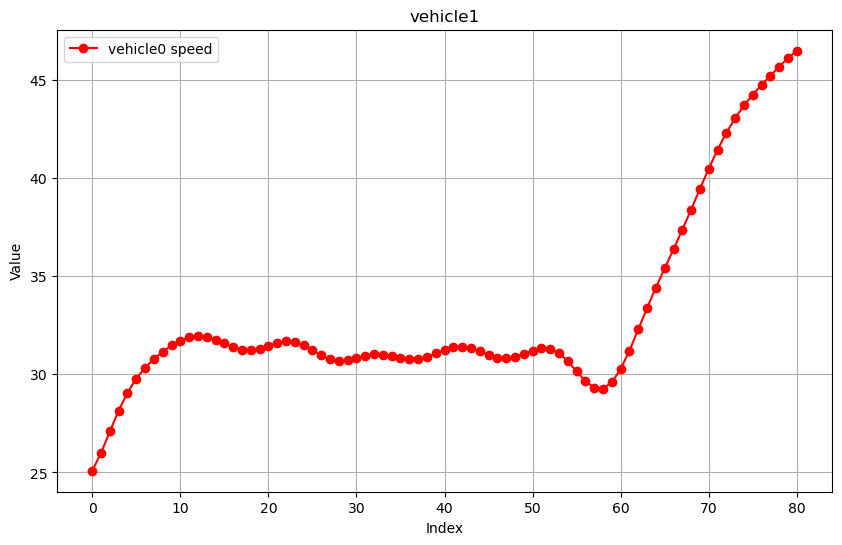

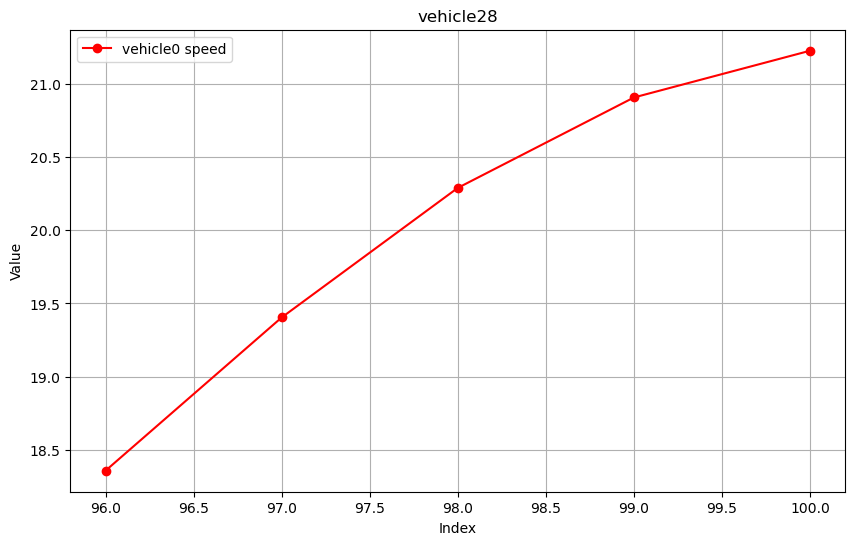

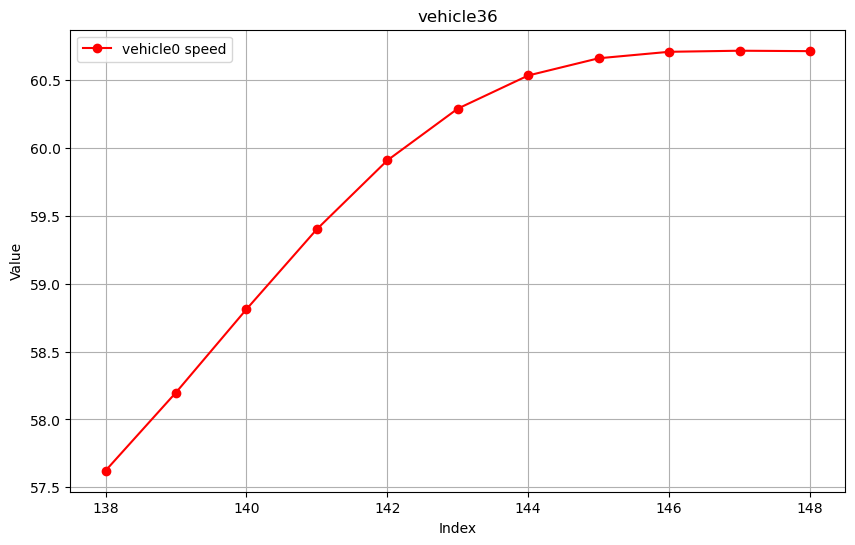

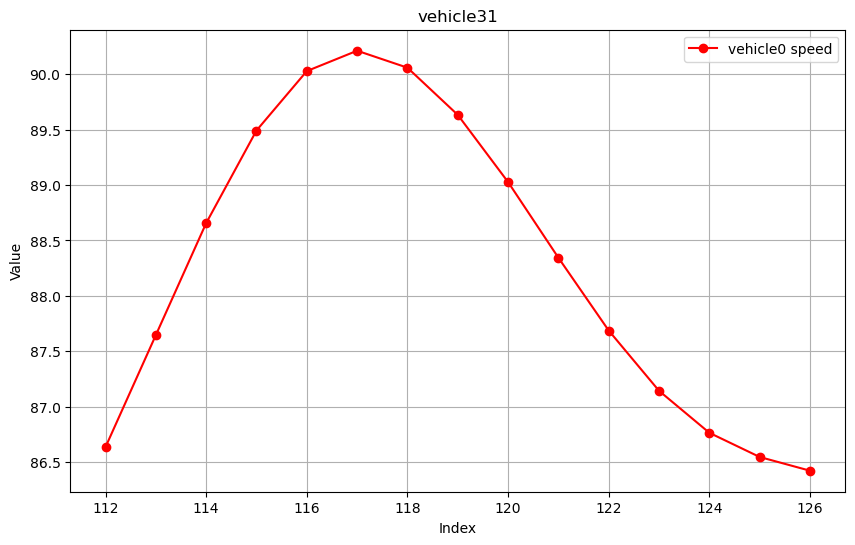

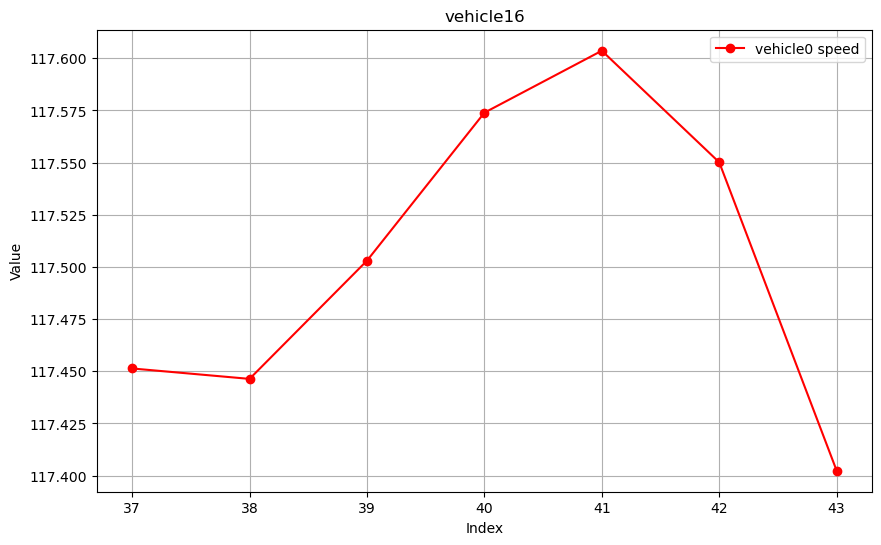

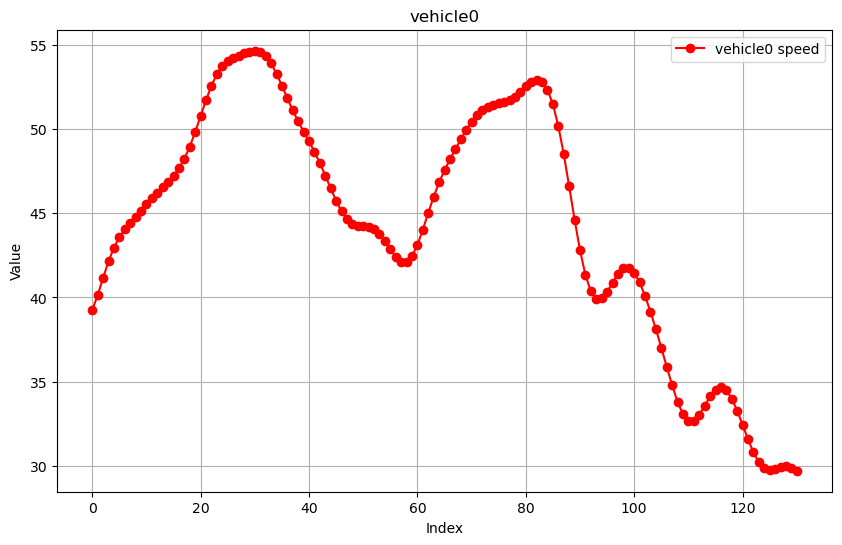

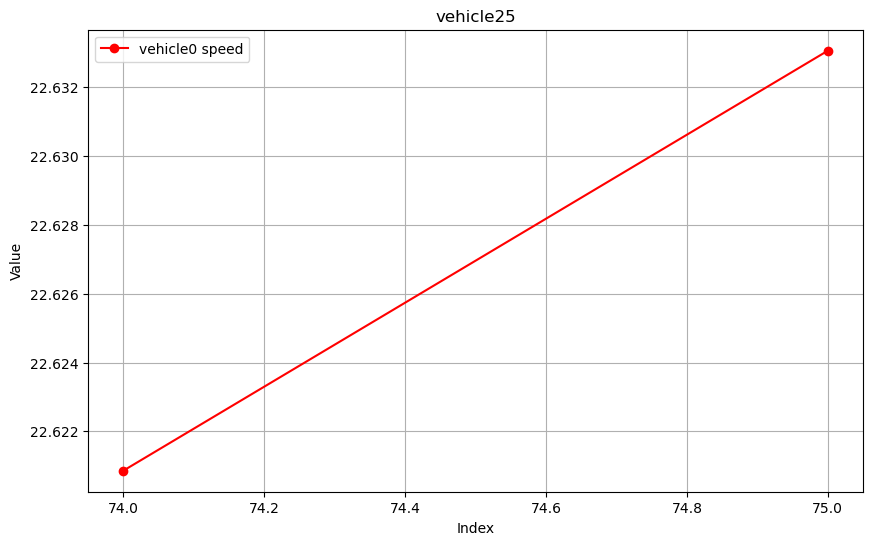

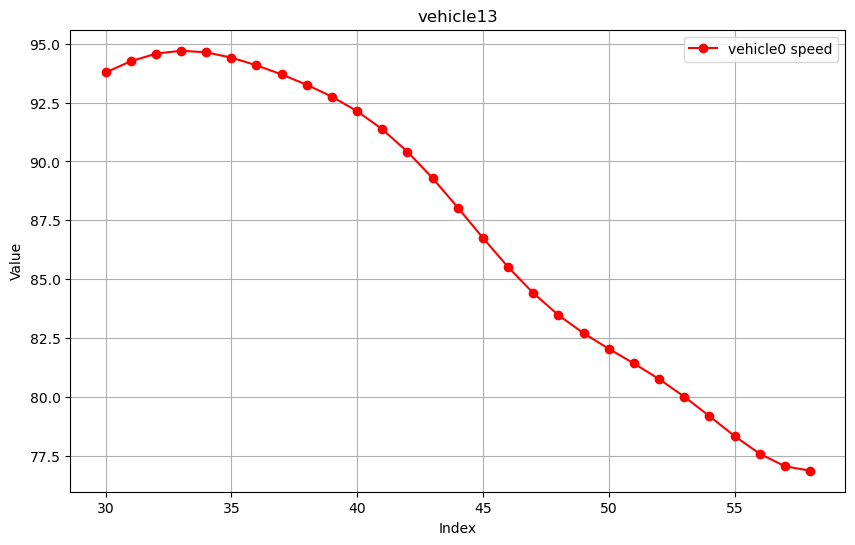

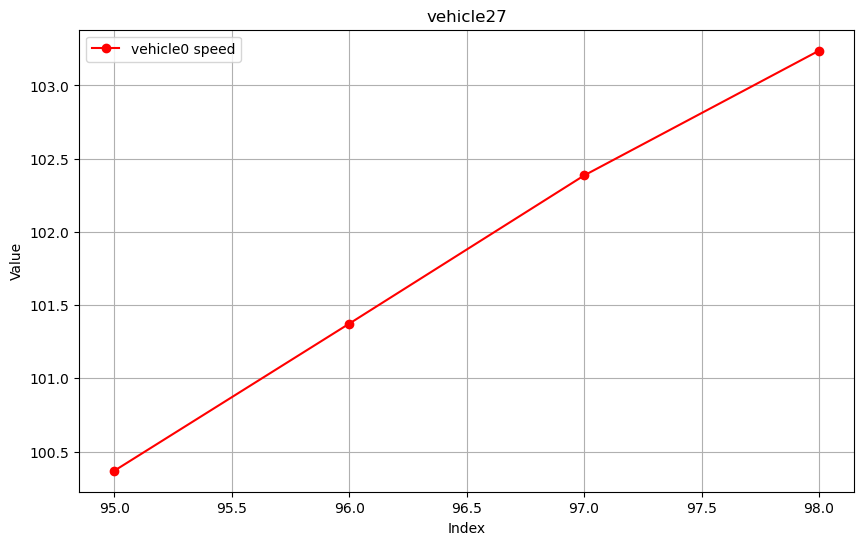

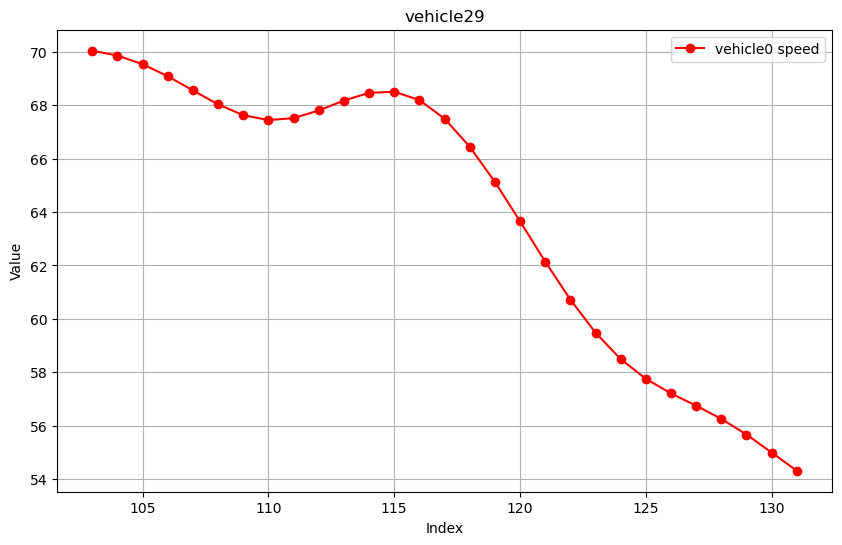

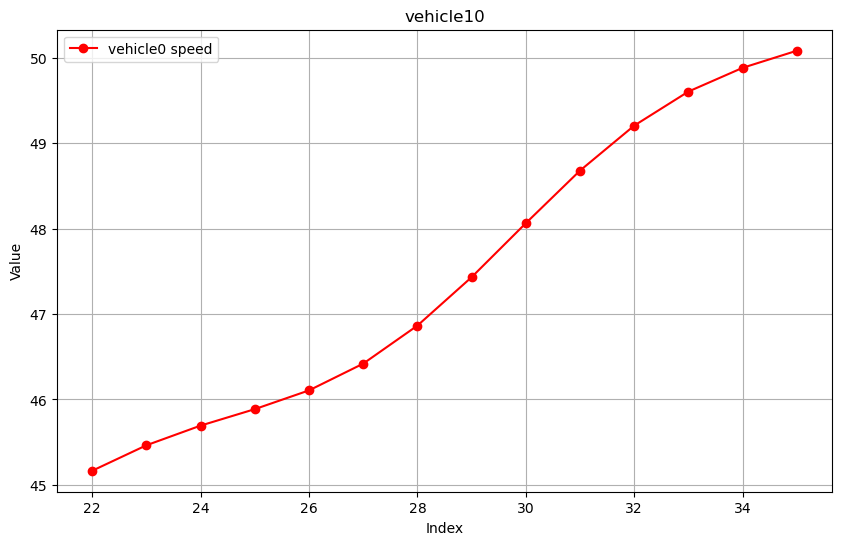

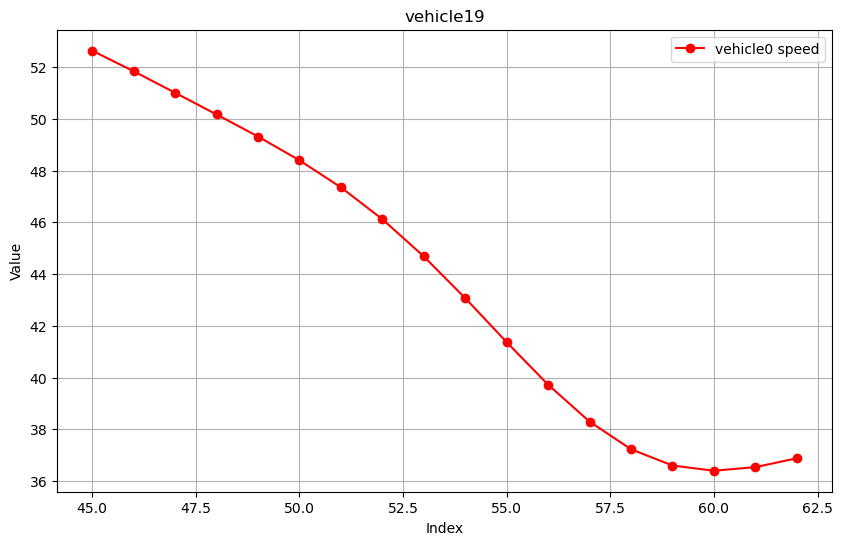

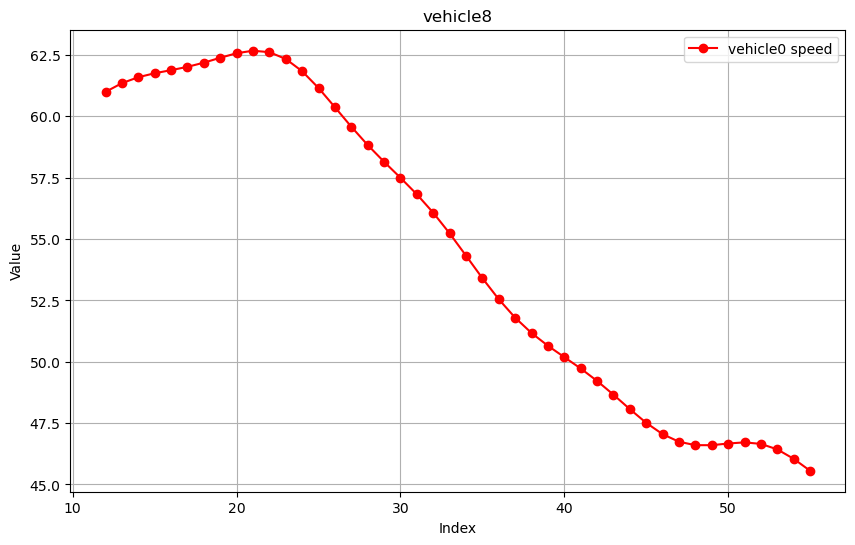

In [117]:
new_velocity_dic = {}
for vehicle in all_vehicles:
    x = np.arange(0, len(velocity_dic[vehicle]))
    data = np.array(velocity_dic[vehicle], dtype=np.float64)
    data = np.where(data == None, np.nan, data)
    data_filled = np.where(np.isnan(data), np.nanmean(data), data)
    smoothed = gaussian_filter1d(data_filled, sigma=10)
    smoothed = np.where(np.isnan(data), np.nan, smoothed)
    y = list(smoothed)
    
    result = []
    for i, j in zip(y, ego_speed):
        if math.isnan(i) or math.isnan(j):
            result.append(float('nan'))
        else:
            result.append(i + j)
    new_velocity_dic[vehicle] = result         
    plt.figure(figsize=(10, 6))
    plt.plot(x, result, color='red', marker='o', label='vehicle0 speed')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title(vehicle)
    plt.legend()
    plt.grid(True)
    plt.show()

In [32]:
all_vehicles

{'vehicle0',
 'vehicle1',
 'vehicle10',
 'vehicle13',
 'vehicle16',
 'vehicle19',
 'vehicle25',
 'vehicle27',
 'vehicle28',
 'vehicle29',
 'vehicle31',
 'vehicle36',
 'vehicle8'}

In [33]:
vehicle = 'vehicle0'
center_points = cal_center_points(vehicle)
center_depths = extract_depth(center_points)
velocity = cal_velocity(center_depths)
print(f"{vehicle} velocity: {velocity}")
print(len(velocity))


vehicle0 velocity: [72.29173971258179, 10.308063640500107, 2.945628392100467, 44.227832223043556, 71.41722707773022, 16.5972572346819, 90.37706562879065, 2.4414337437627873, 0.0, 0.9112932009933106, 3.8410916493035097, 13.44003307423373, 17.18757326373399, 0.9112932009933106, 2.441433743762779, 36.30702076295355, 5.4678443943542545, 39.9365609767302, 101.68980075256158, 9.785459556110002, 9.032247545091176, 69.90457001868737, 22.759219675959606, 94.05814535728318, 27.592793342899785, 27.5784913665199, 14.39058423922972, 15.523216583786215, 34.911854142832915, 59.803696562929936, 41.058827541399936, 115.28113974021653, 28.774928064163298, 55.63176099652112, 23.766197883162082, 12.084627059901418, 53.776597777846035, 9.7890808665446, 20.17615440811163, 43.780312519124124, 19.918631578096225, 27.263161308078644, 18.24519765220072, 19.516852796347017, 29.96141052216243, 2.516185879975773, 53.17785240169196, 42.793192808154686, 41.90642339286022, 65.67942644475217, 16.84932884467706, 27.715

In [118]:
import json
file_path = 'content/velocity.json'
with open(file_path, 'w', encoding='utf-8') as json_file:
        json.dump(new_velocity_dic, json_file, ensure_ascii=False, indent=4)